In [ ]:
# Data download — DVF 2015-2025 from data.gouv.fr (geo-DVF)

import gzip, shutil, sys, urllib.request
from pathlib import Path

#here add the updated url sjould it change
GEODVF_URL = 'https://files.data.gouv.fr/geo-dvf/latest/csv/{year}/full.csv.gz'


# def function used later. This function is to take into input the DF online URL path and the local path. the aim is to download the needed files only if they were not downloaded yet
def download_geodvf_year(year, output_dir, keep_gz=False):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    out_csv = output_dir / f'{year}-full.csv'
    if out_csv.exists() and out_csv.stat().st_size > 0:
        print(f'  {year}: {out_csv.name} already exists '
              f'({out_csv.stat().st_size/1e6:.0f} MB) — skipping')
        return out_csv

    out_gz = output_dir / f'{year}-full.csv.gz'
    url = GEODVF_URL.format(year=year)
    print(f'  {year}: downloading {url}')

    def hook(blocks, block_size, total):
        if total > 0:
            done = blocks * block_size
            pct = min(100, done * 100 / total)
            sys.stdout.write(f'\r    {pct:5.1f}%  ({done/1e6:6.1f} / {total/1e6:6.1f} MB)')
            sys.stdout.flush()

    try:
        urllib.request.urlretrieve(url, out_gz, reporthook=hook)
        sys.stdout.write('\n')
    except Exception as e:
        print(f'    download failed: {e}')
        if out_gz.exists():
            out_gz.unlink()
        return None

    print(f'  {year}: decompressing -> {out_csv.name}')
    try:
        with gzip.open(out_gz, 'rb') as fin, open(out_csv, 'wb') as fout:
            shutil.copyfileobj(fin, fout, length=16 * 1024 * 1024)
    except Exception as e:
        print(f'    decompression failed: {e}')
        if out_csv.exists():
            out_csv.unlink()
        return None

    if not keep_gz:
        out_gz.unlink()

    print(f'  {year}: done — {out_csv.name} ({out_csv.stat().st_size/1e6:.0f} MB)')
    return out_csv


OUTPUT_DIR = '/Users/castetpaul/Downloads/MemoireDATA'
YEARS = list(range(2015, 2026))   # [2015..2025 ]

for y in YEARS:
    download_geodvf_year(y, OUTPUT_DIR)

print('\nDone.')


  2015: 2015-full.csv already exists (479 MB) — skipping
  2016: 2016-full.csv already exists (512 MB) — skipping
  2017: 2017-full.csv already exists (590 MB) — skipping
  2018: 2018-full.csv already exists (579 MB) — skipping
  2019: 2019-full.csv already exists (546 MB) — skipping
  2020: 2020-full.csv already exists (143 MB) — skipping
  2021: 2021-full.csv already exists (814 MB) — skipping
  2022: 2022-full.csv already exists (815 MB) — skipping
  2023: 2023-full.csv already exists (663 MB) — skipping
  2024: 2024-full.csv already exists (608 MB) — skipping
  2025: 2025-full.csv already exists (646 MB) — skipping

Done.


In [ ]:
# Imports + DVF load (2015-2025)

import sys
print(sys.version)
print(sys.executable)

# Standard library
import json

# Data & scientific computing
import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import cdist

# Visualisation
import matplotlib.pyplot as plt

# Machine learning
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Statsmodels
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS

# PART 1: Load and preprocess DVF data

DATA_DIR = '/Users/castetpaul/Downloads/MemoireDATA'
dvf_files = [f'{DATA_DIR}/{y}-full.csv' for y in range(2015, 2026)]

df = pd.concat(
    [pd.read_csv(f, na_values=['NA', '?'], low_memory=False) for f in dvf_files],
    ignore_index=True
)

print(f"Total transactions after merge: {len(df):,}")
print(f"Date range (string): {df['date_mutation'].min()} to {df['date_mutation'].max()}")

# Convert columns to proper types
df['date_mutation']        = pd.to_datetime(df['date_mutation'], errors='coerce')
df['valeur_fonciere']      = pd.to_numeric(df['valeur_fonciere'], errors='coerce')
df['longitude']            = pd.to_numeric(df['longitude'], errors='coerce')
df['latitude']             = pd.to_numeric(df['latitude'], errors='coerce')
df['surface_reelle_bati']  = pd.to_numeric(df['surface_reelle_bati'], errors='coerce')

print(f"\nDate range (datetime): {df['date_mutation'].min()} to {df['date_mutation'].max()}")
print("\nMissing values:")
print(df[['valeur_fonciere', 'longitude', 'latitude', 'surface_reelle_bati']].isnull().sum())
print("\nProperty value statistics:")
print(df['valeur_fonciere'].describe())


3.11.15 (main, Mar 11 2026, 17:14:47) [Clang 20.1.8 ]
/opt/anaconda3/envs/tf-metal/bin/python
Total transactions after merge: 36,742,897
Date range (string): 2015-01-01 to 2025-12-31

Date range (datetime): 2015-01-01 00:00:00 to 2025-12-31 00:00:00

Missing values:
valeur_fonciere          415078
longitude                943403
latitude                 943403
surface_reelle_bati    23236768
dtype: int64

Property value statistics:
count    3.632782e+07
mean     1.294014e+06
std      1.424189e+07
min      1.000000e-02
25%      6.200000e+04
50%      1.545750e+05
75%      2.850000e+05
max      1.415000e+10
Name: valeur_fonciere, dtype: float64


In [ ]:
# PART 2: Load Line 5 STOPS // as before, please update the correct path to the files

with open('/Users/castetpaul/Downloads/MemoireDATA/MMM_MMM_ArretsTram.json', 'r') as f:
    tram_stops_data = json.load(f)

with open('/Users/castetpaul/Downloads/MemoireDATA/MMM_MMM_CodesPostaux.geojson', 'r') as f:
    postal_codes = json.load(f)

# Extract Line 5 stops, averaging positions per station
line5_stops_dict = {}
for feat in tram_stops_data['features']:
    lignes = [l.strip() for l in feat['properties']['lignes_passantes'].split(';')]
    if '5' in lignes:
        name = feat['properties']['description']
        lon, lat = feat['geometry']['coordinates'][:2]
        if name not in line5_stops_dict:
            line5_stops_dict[name] = {'lats': [lat], 'lons': [lon]}
        else:
            line5_stops_dict[name]['lats'].append(lat)
            line5_stops_dict[name]['lons'].append(lon)

# Average positions for each stop
line5_array = np.array([
    [np.mean(info['lats']), np.mean(info['lons'])]
    for info in line5_stops_dict.values()
])

print(f"\nLine 5 stops: {len(line5_array)}")
for name, info in line5_stops_dict.items():
    avg_lat = np.mean(info['lats'])
    avg_lon = np.mean(info['lons'])
    print(f"  {name}: {avg_lat:.4f}, {avg_lon:.4f}")


Line 5 stops: 27
  Boutonnet - Cité des Arts: 43.6226, 3.8681
  Stade Philippidès: 43.6190, 3.8695
  Albert 1er - Saint-Charles: 43.6165, 3.8741
  Albert 1er - Jardin des Plantes: 43.6148, 3.8737
  Peyrou - Arc de Triomphe: 43.6117, 3.8723
  Saint-Guilhem - Courreau: 43.6080, 3.8737
  Gambetta: 43.6056, 3.8740
  Clapiers: 43.6537, 3.8728
  Montferrier-sur-Lez: 43.6514, 3.8673
  Grés de Montpellier: 43.5929, 3.8235
  Agropolis: 43.6460, 3.8686
  Plan des 4 Seigneurs: 43.6442, 3.8611
  CNRS - Zoo de Lunaret: 43.6382, 3.8659
  Pôle Chimie Balard: 43.6340, 3.8680
  Université Paul Valéry: 43.6300, 3.8696
  Saint-Éloi - Docteur Pezet: 43.6270, 3.8667
  Parc Clemenceau: 43.6033, 3.8720
  Place du 8 mai 1945: 43.6013, 3.8681
  Cité Créative - Parc Montcalm: 43.6017, 3.8620
  Chamberte - Les Roses: 43.6026, 3.8546
  Estanove: 43.6007, 3.8493
  Yves du Manoir: 43.5951, 3.8499
  Ovalie: 43.5914, 3.8477
  Parc Bagatelle: 43.5936, 3.8423
  Parc Font-Colombe: 43.5954, 3.8372
  Parc des Bouisses: 4

In [ ]:
# PART 3: Distance calculation function tbused later

def calculate_distance_to_line5(df_input):
    """
    Calculate minimum distance from each property to the nearest Line 5 STOP.
    Uses Haversine-approximate conversion.
    """
    property_coords = df_input[['latitude', 'longitude']].values
    mean_lat = np.radians(property_coords[:, 0].mean())
    
    property_scaled = np.column_stack([
        property_coords[:, 0] * 111.32, #112.32 is the value to multiply decimal degrees into kilometres (I use this to get the Euclidienne distance)
        property_coords[:, 1] * 111.32 * np.cos(mean_lat)
    ])
    line5_scaled = np.column_stack([
        line5_array[:, 0] * 111.32,
        line5_array[:, 1] * 111.32 * np.cos(mean_lat)
    ])
    
    distances = cdist(property_scaled, line5_scaled, metric='euclidean')
    min_distances_km = distances.min(axis=1)
    return min_distances_km

In [ ]:
# PART 4: Filter to Line 5 postal codes

print("\nPostal codes in the dataset:")
for feature in postal_codes['features']:
    cod_postal = feature['properties']['cod_postal']
    area = feature['properties']['st_area_sh']
    print(f"  Code Postal: {cod_postal}, Area: {area/1e6:.2f} km²")

line5_postal_codes = [34000, 34070, 34080, 34090, 34170]

# Using nullable Int64 so the Bustram cells can use integer postal-code
# changes the dtype of df['code_postal'] into Int64 so that it works in the filter

df['code_postal'] = pd.to_numeric(df['code_postal'], errors='coerce').astype('Int64')

df_filtered = df[df['code_postal'].isin(line5_postal_codes)].copy()

print(f"\nOriginal dataset: {len(df):,} transactions")
print(f"Filtered to Line 5 postal codes: {len(df_filtered):,} transactions")
print(f"Reduction: {(1 - len(df_filtered)/len(df))*100:.1f}%")

# Verify years are now complete
print("\nTransactions by year after fix:")
print(df_filtered['date_mutation'].dt.year.value_counts().sort_index())


Postal codes in the dataset:
  Code Postal: 34980, Area: 7.37 km²
  Code Postal: 34880, Area: 7.03 km²
  Code Postal: 34090, Area: 12.94 km²
  Code Postal: 34000, Area: 24.11 km²
  Code Postal: 34750, Area: 32.16 km²
  Code Postal: 34670, Area: 11.88 km²
  Code Postal: 34070, Area: 12.50 km²
  Code Postal: 34080, Area: 7.56 km²
  Code Postal: 34160, Area: 80.51 km²
  Code Postal: 34740, Area: 8.82 km²
  Code Postal: 34920, Area: 6.10 km²
  Code Postal: 34830, Area: 10.77 km²
  Code Postal: 34470, Area: 8.51 km²
  Code Postal: 34170, Area: 11.19 km²
  Code Postal: 34730, Area: 8.99 km²
  Code Postal: 34790, Area: 16.72 km²
  Code Postal: 34990, Area: 11.25 km²
  Code Postal: 34680, Area: 9.17 km²
  Code Postal: 34430, Area: 13.37 km²
  Code Postal: 34660, Area: 41.06 km²
  Code Postal: 34570, Area: 33.76 km²
  Code Postal: 34690, Area: 32.27 km²
  Code Postal: 34970, Area: 32.28 km²

Original dataset: 36,742,897 transactions
Filtered to Line 5 postal codes: 158,247 transactions
Reducti

In [ ]:

# 

# PART 5: Housing filter + temporal variables

df_housing = df_filtered[
    (df_filtered['type_local'].isin(['Maison', 'Appartement'])) &
    (df_filtered['valeur_fonciere'] > 0) &
    (df_filtered['longitude'].notna()) &
    (df_filtered['latitude'].notna())
].copy()

df_housing['year'] = df_housing['date_mutation'].dt.year
df_housing['month'] = df_housing['date_mutation'].dt.month
df_housing['year_month'] = df_housing['date_mutation'].dt.to_period('M')


In [ ]:
# Finer geography: 500m × 500m grid cells (and optional IRIS)



# 5 postal codes is too few to use as fixed effects or clusters. so i add two finer geographic IDs:
#   - grid_id : synthetic 500m × 500m grid cells 
#   - code_iris : INSEE IRIS zones (only if a contour file is present
#                 in DATA_DIR; falls back gracefully if not)
# Either can be used as cluster / FE in robustness regressions.

import os

def add_grid_id(df_in, grid_km=0.5, lat_col='latitude', lon_col='longitude'):
    """Add a grid_id column based on (lat, lon) at grid_km resolution.
    Requires non-NaN coordinates in the inputs."""
    df_out = df_in.copy()
    if df_out[lat_col].isna().any() or df_out[lon_col].isna().any():
        raise ValueError("add_grid_id requires non-NaN lat/lon. Filter first.")
    mean_lat_rad = np.radians(df_out[lat_col].mean())
    lat_idx = (df_out[lat_col]  * 111.32 / grid_km).round().astype(int)
    lon_idx = (df_out[lon_col] * 111.32 * np.cos(mean_lat_rad) / grid_km).round().astype(int)
    df_out['grid_id'] = lat_idx.astype(str) + '_' + lon_idx.astype(str)
    return df_out

# Apply to the housing dataset (coords guaranteed non-NaN here)
df_housing = add_grid_id(df_housing, grid_km=0.5)
print(f"Grid cells (500m): {df_housing['grid_id'].nunique():,} unique cells "
      f"across {len(df_housing):,} obs")
print("Sample grid cell sizes (top 10):")
print(df_housing['grid_id'].value_counts().head(10))

# ── Optional IRIS spatial join ──────────────────────────────── // it would work better / be cleaner to use the IRIS join but I do not have it
# Looks for an IRIS contour file in DATA_DIR. do rename the file if I get it or you get it:
DATA_DIR_LOCAL = '/Users/castetpaul/Downloads/MemoireDATA'
IRIS_CANDIDATES = [
    'CONTOURS-IRIS.geojson'
]
iris_path = None # I don't have IRIS but this is future work to be done should i get the data access 
for c in IRIS_CANDIDATES:
    p = os.path.join(DATA_DIR_LOCAL, c)
    if os.path.exists(p):
        iris_path = p
        break

HAS_IRIS = False
if iris_path is not None:
    try:
        import geopandas as gpd
        from shapely.geometry import Point

        print(f"\nLoading IRIS contours from {iris_path}...")
        iris_gdf = gpd.read_file(iris_path)
        # Standardize the column name (varies between sources)
        iris_id_col = next(
            (c for c in ['CODE_IRIS', 'code_iris', 'DCOMIRIS', 'IRIS'] if c in iris_gdf.columns),
            None
        )
        if iris_id_col is None:
            print(f"   Could not find IRIS code column in {list(iris_gdf.columns)} — skipping")
        else:
            # Project both to a metric CRS for safety; sjoin in WGS84 also fine
            iris_gdf = iris_gdf.to_crs(epsg=4326)
            iris_gdf = iris_gdf[[iris_id_col, 'geometry']].rename(columns={iris_id_col: 'code_iris'})

            pts = gpd.GeoDataFrame(
                df_housing.copy(),
                geometry=gpd.points_from_xy(df_housing['longitude'], df_housing['latitude']),
                crs='EPSG:4326'
            )
            joined = gpd.sjoin(pts, iris_gdf, how='left', predicate='within')
            df_housing = pd.DataFrame(joined.drop(columns=['geometry', 'index_right']))
            HAS_IRIS = True
            n_match = df_housing['code_iris'].notna().sum()
            print(f"  IRIS join: {n_match:,}/{len(df_housing):,} matched "
                  f"({df_housing['code_iris'].nunique()} unique IRIS)")
    except ImportError:
        print("  geopandas not installed — using grid_id only")
    except Exception as e:
        print(f"  IRIS load failed ({e}) — using grid_id only")
else:
    print("\nNo IRIS contour file found in DATA_DIR.")
    print("  To enable IRIS FE: download CONTOURS-IRIS from")
    print("  https://geoservices.ign.fr/contoursiris and place under DATA_DIR.")
    print("  For now, using grid_id (500m cells) as the finer geographic unit.")

print(f"\nFiner geography available: grid_id={'ok' if 'grid_id' in df_housing.columns else 'not ok'}, "
      f"code_iris={'ok' if HAS_IRIS else 'not ok'}")


Grid cells (500m): 256 unique cells across 64,013 obs
Sample grid cell sizes (top 10):
grid_id
9709_625    1744
9710_625    1715
9708_624    1354
9708_626    1342
9709_624    1287
9708_625    1111
9709_623    1061
9708_628    1045
9707_628    1018
9711_618     977
Name: count, dtype: int64

No IRIS contour file found in DATA_DIR.
  To enable IRIS FE: download CONTOURS-IRIS from
  https://geoservices.ign.fr/contoursiris and place under DATA_DIR.
  For now, using grid_id (500m cells) as the finer geographic unit.

Finer geography available: grid_id=✓, code_iris=✗


In [ ]:


# PART 6: Calculate distances + treatment indicators

print("\nCalculating distances to Line 5...")
df_housing['distance_line5_km'] = calculate_distance_to_line5(df_housing)

df_housing['treated_500m'] = (df_housing['distance_line5_km'] < 0.5).astype(int)
df_housing['treated_1km'] = (df_housing['distance_line5_km'] < 1.0).astype(int)



Calculating distances to Line 5...


In [ ]:


# PART 7: Summary statistics

print(f"\nFinal housing dataset: {len(df_housing):,} properties")
print("\nDistance to Line 5 Statistics:")
print(df_housing['distance_line5_km'].describe())

print(f"\nProperties < 500m from Line 5: {df_housing['treated_500m'].sum():,} ({df_housing['treated_500m'].mean()*100:.1f}%)")
print(f"Properties < 1km from Line 5: {df_housing['treated_1km'].sum():,} ({df_housing['treated_1km'].mean()*100:.1f}%)")

print("\nTransactions by Postal Code:")
print(df_housing['code_postal'].value_counts().sort_index())

print("\nTransactions by Year:")
print(df_housing['year'].value_counts().sort_index())



Final housing dataset: 64,013 properties

Distance to Line 5 Statistics:
count    64013.000000
mean         1.329917
std          1.019259
min          0.017749
25%          0.456956
50%          1.168707
75%          1.971615
max          5.027103
Name: distance_line5_km, dtype: float64

Properties < 500m from Line 5: 18,039 (28.2%)
Properties < 1km from Line 5: 29,174 (45.6%)

Transactions by Postal Code:
code_postal
34000    21142
34070    18330
34080     8261
34090    10768
34170     5512
Name: count, dtype: Int64

Transactions by Year:
year
2015    6911
2016    6936
2017    8149
2018    7028
2019    3162
2020     579
2021    7032
2022    7196
2023    6091
2024    5114
2025    5815
Name: count, dtype: int64


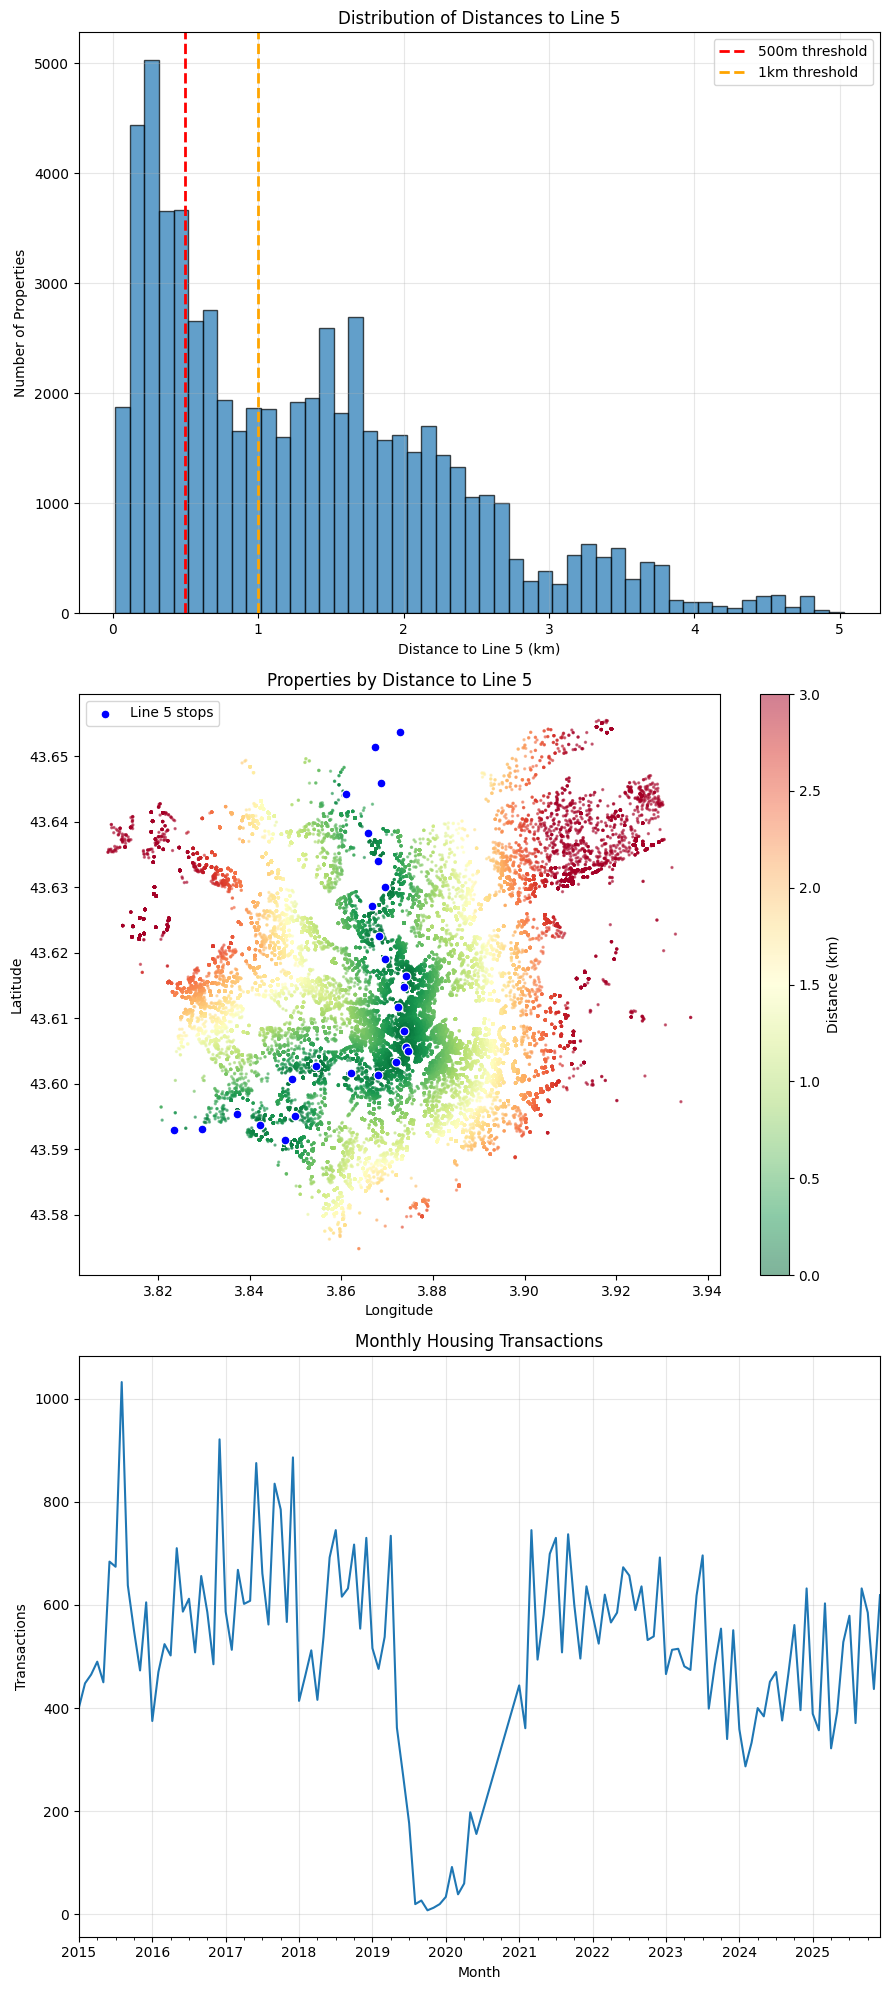

In [ ]:


# PART 8: Visualizations

fig, axes = plt.subplots(3, 1, figsize=(9, 20))

# 8a. Distance histogram
axes[0].hist(df_housing['distance_line5_km'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.5, color='r', linestyle='--', linewidth=2, label='500m threshold')
axes[0].axvline(x=1.0, color='orange', linestyle='--', linewidth=2, label='1km threshold')
axes[0].set_xlabel('Distance to Line 5 (km)')
axes[0].set_ylabel('Number of Properties')
axes[0].set_title('Distribution of Distances to Line 5')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 8b. Map colored by distance
scatter = axes[1].scatter(
    df_housing['longitude'], df_housing['latitude'],
    c=df_housing['distance_line5_km'], cmap='RdYlGn_r',
    alpha=0.5, s=2, vmin=0, vmax=3
)
plt.colorbar(scatter, ax=axes[1], label='Distance (km)')
# Plot Line 5 stops
axes[1].scatter(line5_array[:, 1], line5_array[:, 0],
                c='blue', s=40, marker='o', edgecolors='white',
                linewidths=0.8, zorder=5, label='Line 5 stops')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Properties by Distance to Line 5')
axes[1].legend()

# 8c. Monthly transaction counts
monthly_counts = df_housing['year_month'].value_counts().sort_index()
monthly_counts.plot(ax=axes[2])
axes[2].set_title('Monthly Housing Transactions')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Transactions')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
 # DID PART 1: Preparation of the DiD variables
 
df_housing['price_m2'] = df_housing['valeur_fonciere'] / df_housing['surface_reelle_bati']

df_did = df_housing[
    (df_housing['price_m2'] >= 500) &
    (df_housing['price_m2'] <= 10_000) &
    (df_housing['surface_reelle_bati'] > 0)
].copy()

# 2020 diagnostic, usually a very small sample in the dataset I downloaded so verify that this is indeed a small sample as i had as of the writting of the paper
counts_2020 = (df_did['year'] == 2020).sum()
print(f"Observations in 2020 (after outlier filter): {counts_2020}")
print("Yearly counts (full DiD candidate sample):")
print(df_did['year'].value_counts().sort_index())

# Thus I decided to drop 2020 to avoid the COVID-lockdown confound (Mar-May 2020 effectively halted real-estate transactions).
# The construction-start cutoff is Apr 2019, so dropping 2020 doesn't affect identification but cleans up the post-period.
n_before = len(df_did)
df_did = df_did[df_did['year'] != 2020].copy()
print(f"\nDropped 2020 (COVID confound): {n_before - len(df_did):,}")
print(f"Working sample: {len(df_did):,}")

# Donut treatment definition
df_did['treatment'] = np.where(
    df_did['distance_line5_km'] < 0.5, 1,
    np.where(df_did['distance_line5_km'] > 1.0, 0, np.nan)
)
df_did_clean = df_did.dropna(subset=['treatment']).copy()
df_did_clean['treatment'] = df_did_clean['treatment'].astype(int)

print(f"\nDiD sample (excluding 500m-1km buffer): {len(df_did_clean):,}")
print(f"  Treatment (<500m): {df_did_clean['treatment'].sum():,}")
print(f"  Control  (>1km):   {(df_did_clean['treatment'] == 0).sum():,}")

# Temporal indicators (month-precision; construction began Apr 2019)
df_did_clean['post_construction_start'] = (
    (df_did_clean['year'] > 2019) |
    ((df_did_clean['year'] == 2019) & (df_did_clean['month'] >= 4))
).astype(int)

df_did_clean['post_construction_advanced'] = (df_did_clean['year'] >= 2022).astype(int)

# Period bins aligned to the two cutoffs used in regressions:
#   pre              = ≤ 2018           (post_construction_start = 0)
#   construction     = 2019–2021        (start = 1, advanced = 0)
#   construction_adv = 2022–2025        (advanced = 1)
df_did_clean['period'] = pd.cut(
    df_did_clean['year'],
    bins=[2014, 2018, 2021, 2026],
    labels=['pre (≤2018)',
            'construction (2019–2021)',
            'construction_advanced (2022+)']
)

df_did_clean['did_construction_start']    = (
    df_did_clean['treatment'] * df_did_clean['post_construction_start']
)
df_did_clean['did_construction_advanced'] = (
    df_did_clean['treatment'] * df_did_clean['post_construction_advanced']
)

df_did_clean['log_price_m2'] = np.log(df_did_clean['price_m2'])

print(f"\nTemporal x treatment distribution:")
print(df_did_clean.groupby(['period', 'treatment'], observed=False).size().unstack(fill_value=0))

print(f"\nYearly counts (final DiD sample):")
print(df_did_clean['year'].value_counts().sort_index())


Observations in 2020 (after outlier filter): 528
Yearly counts (full DiD candidate sample):
year
2015    5930
2016    6292
2017    7266
2018    6586
2019    2786
2020     528
2021    6465
2022    6550
2023    5541
2024    4567
2025    5516
Name: count, dtype: int64

Dropped 2020 (COVID confound): 528
Working sample: 57,499

DiD sample (excluding 500m-1km buffer): 47,306
  Treatment (<500m): 15,977
  Control  (>1km):   31,329

Temporal x treatment distribution:
treatment                          0     1
period                                    
pre (≤2018)                    14405  7293
construction (2019–2021)        4976  2459
construction_advanced (2022+)  11948  6225

Yearly counts (final DiD sample):
year
2015    5046
2016    5300
2017    6008
2018    5344
2019    2225
2021    5210
2022    5336
2023    4600
2024    3676
2025    4561
Name: count, dtype: int64


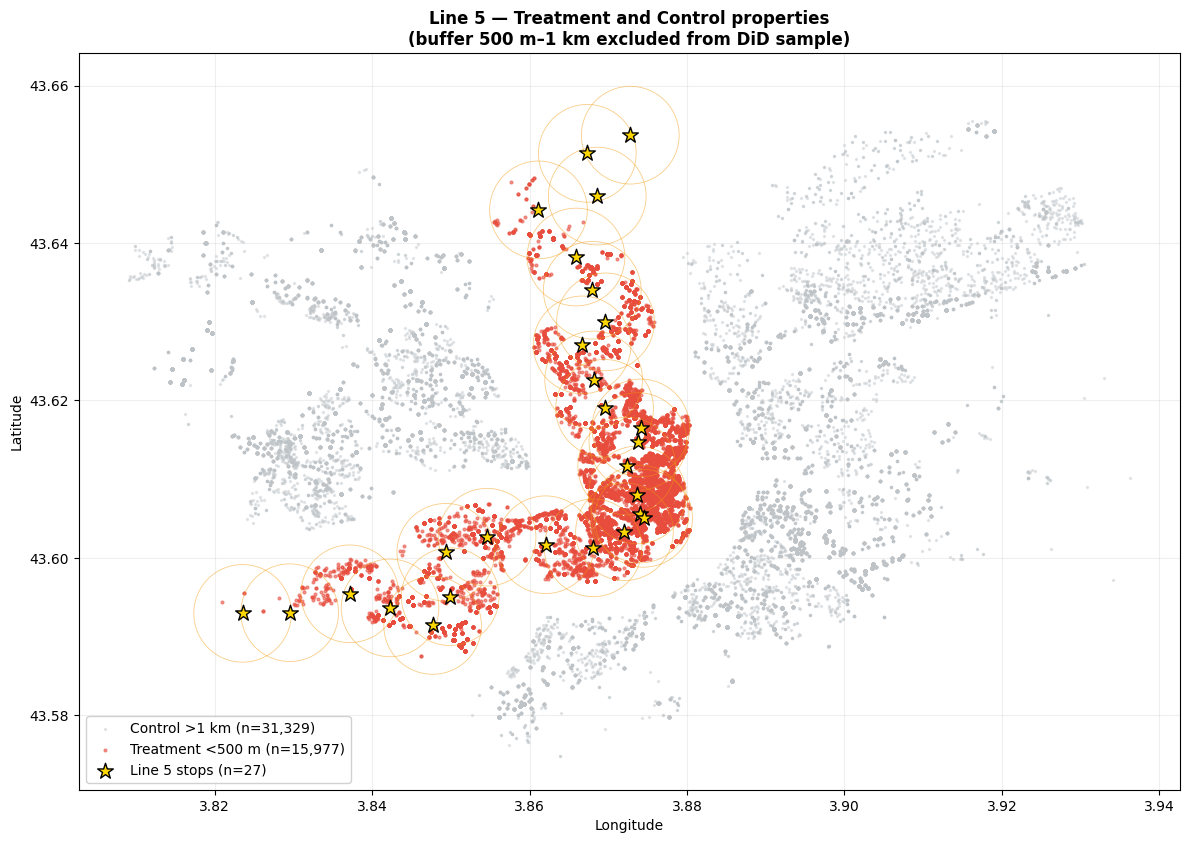

In [ ]:

# VIZUALISATION : MAP — Line 5: Treatment vs Control properties

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 10))

# Control properties (>1 km from any Line 5 stop) — light grey, behind
ctrl = df_did_clean[df_did_clean['treatment'] == 0]
ax.scatter(ctrl['longitude'], ctrl['latitude'],
           c='#bdc3c7', s=2, alpha=0.35,
           label=f'Control >1 km (n={len(ctrl):,})', zorder=2)

# Treatment properties (<500 m from a Line 5 stop) — red, on top
treat = df_did_clean[df_did_clean['treatment'] == 1]
ax.scatter(treat['longitude'], treat['latitude'],
           c='#e74c3c', s=4, alpha=0.55,
           label=f'Treatment <500 m (n={len(treat):,})', zorder=4)

# Line 5 stops — gold stars
ax.scatter(line5_array[:, 1], line5_array[:, 0],
           c='gold', s=140, marker='*',
           edgecolors='black', linewidths=1.0,
           label=f'Line 5 stops (n={len(line5_array)})', zorder=6)

# 500 m buffer rings around each stop
for lat, lon in line5_array:
    radius_lon = 0.5 / (111.32 * np.cos(np.radians(lat)))
    circle = plt.Circle((lon, lat), radius_lon,
                        fill=False, color='#f39c12',
                        linewidth=0.6, alpha=0.5, zorder=5)
    ax.add_patch(circle)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Line 5 — Treatment and Control properties\n'
             '(buffer 500 m–1 km excluded from DiD sample)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower left', framealpha=0.9)
ax.set_aspect('equal')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:

# DID PART 2: Descriptive statistics 

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS BY TREATMENT GROUP AND PERIOD")
print("=" * 60)

desc = df_did_clean.groupby(['treatment', 'post_construction_start']).agg(
    n=('price_m2', 'count'),
    mean_price_m2=('price_m2', 'mean'),
    median_price_m2=('price_m2', 'median'),
    std_price_m2=('price_m2', 'std'),
    mean_surface=('surface_reelle_bati', 'mean'),
    mean_valeur=('valeur_fonciere', 'mean')
).round(2)

desc.index = desc.index.set_names(['Treatment (<500m)', 'Post-construction (Apr 2019+)'])
print(desc)

print("\n" + "=" * 60)
print("2×2 DiD TABLE — CONSTRUCTION-START EFFECT (Mean Price/m²)")
print("=" * 60)

table_2x2 = (
    df_did_clean
    .groupby(['treatment', 'post_construction_start'])['price_m2']
    .mean()
    .unstack()
)
table_2x2.columns = ['Pre-construction (≤Mar 2019)', 'Post-construction (Apr 2019+)']
table_2x2.index   = ['Control (>1km)', 'Treatment (<500m)']
table_2x2['Difference'] = (
    table_2x2['Post-construction (Apr 2019+)']
    - table_2x2['Pre-construction (≤Mar 2019)']
)
print(table_2x2.round(2))

naive_did = (
    table_2x2.loc['Treatment (<500m)', 'Difference']
    - table_2x2.loc['Control (>1km)', 'Difference']
)
print(f"\nNaïve DiD estimate (construction-start): €{naive_did:.2f}/m²")


DESCRIPTIVE STATISTICS BY TREATMENT GROUP AND PERIOD
                                                     n  mean_price_m2  \
Treatment (<500m) Post-construction (Apr 2019+)                         
0                 0                              15170        3180.14   
                  1                              16159        3498.82   
1                 0                               7690        3241.08   
                  1                               8287        3802.26   

                                                 median_price_m2  \
Treatment (<500m) Post-construction (Apr 2019+)                    
0                 0                                      3052.79   
                  1                                      3461.54   
1                 0                                      3000.00   
                  1                                      3609.09   

                                                 std_price_m2  mean_surface  \
Treatment (<500m) P

In [ ]:

# DID PART 3: DiD REGRESSIONS


def run_ols(y, X, cov='HC1', groups=None, model_name="Model"):
    """OLS with HC1 (default) or cluster-robust SE."""
    if cov == 'cluster':
        if groups is None:
            raise ValueError("groups must be provided for cluster SE")
        n_clusters = groups.nunique()
        if n_clusters < 30:
            print(f" Only {n_clusters} clusters — cluster SE may be downward-biased.")
        model = OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': groups})
        se_label = f"clustered ({n_clusters} clusters)"
    elif cov == 'HC1':
        model = OLS(y, X).fit(cov_type='HC1')
        se_label = "HC1 robust"
    else:
        raise ValueError(f"Unknown cov={cov}")
    print(f"\n{'=' * 60}\n{model_name}\n{'=' * 60}")
    print(model.summary2().tables[1].to_string())
    print(f"R² = {model.rsquared:.4f} | Adj R² = {model.rsquared_adj:.4f} | "
          f"N = {model.nobs:.0f} | SE: {se_label}")
    return model

# Backward-compat alias for cells that still call run_ols_cluster
def run_ols_cluster(y, X, groups, model_name="Model"):
    return run_ols(y, X, cov='cluster', groups=groups, model_name=model_name)

def print_did_result(model, coef_name, label="DiD coefficient"):
    coef = model.params[coef_name]
    se   = model.bse[coef_name]
    pval = model.pvalues[coef_name]
    ci_lo, ci_hi = model.conf_int().loc[coef_name]
    stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else "n.s."
    print(f"\n→ {label}: €{coef:.2f}/m²  (SE={se:.2f}, p={pval:.4f}) {stars}")
    print(f"  95% CI: [{ci_lo:.2f}, {ci_hi:.2f}]")

def section(title):
    print("\n" + "#" * 60)
    print(title)
    print("#" * 60)

# Shared feature engineering
df_did_clean['is_apartment'] = (df_did_clean['type_local'] == 'Appartement').astype(int)
df_did_clean['log_surface']  = np.log(df_did_clean['surface_reelle_bati'])
df_did_clean['quarter']      = ((df_did_clean['month'] - 1) // 3 + 1)

postal_dummies  = pd.get_dummies(df_did_clean['code_postal'], prefix='cp', drop_first=True, dtype=int)
quarter_dummies = pd.get_dummies(df_did_clean['quarter'],     prefix='Q',  drop_first=True, dtype=int)
cluster_var = df_did_clean['code_postal']

HEADLINE_COV = 'HC1'

# M1: Proximity premium
section("MODEL 1: PROXIMITY PREMIUM (pooled)")
X1 = sm.add_constant(df_did_clean[['treatment', 'year']])
model1 = run_ols(df_did_clean['price_m2'], X1, cov=HEADLINE_COV,
                 model_name="Model 1: Proximity Premium + Year Trend")
print_did_result(model1, 'treatment', "Proximity premium")

# M2: Construction-start DiD (no controls)
section("MODEL 2: CONSTRUCTION-START EFFECT (DiD, no controls)")
X2 = sm.add_constant(
    df_did_clean[['treatment', 'post_construction_start',
                  'did_construction_start', 'year']]
)
model2 = run_ols(df_did_clean['price_m2'], X2, cov=HEADLINE_COV,
                 model_name="Model 2: DiD Construction-Start (no controls)")
print_did_result(model2, 'did_construction_start', "Construction-start effect")

# M3: Construction-start DiD with controls + FE
section("MODEL 3: CONSTRUCTION-START DiD WITH CONTROLS + FE")
X3_core = df_did_clean[['treatment', 'post_construction_start',
                         'did_construction_start',
                         'year', 'is_apartment', 'log_surface']]
X3 = sm.add_constant(pd.concat([X3_core, postal_dummies, quarter_dummies], axis=1))
model3 = run_ols(df_did_clean['price_m2'], X3, cov=HEADLINE_COV,
                 model_name="Model 3: DiD Construction-Start with Controls + FE")
print_did_result(model3, 'did_construction_start', "Controlled construction-start effect")

# M3-cl: same as M3 with clustered SE (robustness, low-cluster warning)
section("MODEL 3-cl: SAME AS MODEL 3 WITH CLUSTERED SE (robustness)")
model3_cl = run_ols(df_did_clean['price_m2'], X3, cov='cluster', groups=cluster_var,
                    model_name="Model 3-cl (clustered SE, 5 postal-code clusters)")
print_did_result(model3_cl, 'did_construction_start',
                 "Construction-start effect (clustered SE)")

# M3b: log specification
section("MODEL 3b: CONSTRUCTION-START DiD — LOG SPECIFICATION")
model3b = run_ols(df_did_clean['log_price_m2'], X3, cov=HEADLINE_COV,
                  model_name="Model 3b: DiD Construction-Start — log(price/m²)")
coef_log = model3b.params['did_construction_start']
pval_log = model3b.pvalues['did_construction_start']
stars = "***" if pval_log < 0.01 else "**" if pval_log < 0.05 else "*" if pval_log < 0.1 else "n.s."
print(f"\n→ Construction-start effect (log): {coef_log:.4f} ≈ {coef_log*100:.2f}%  "
      f"(p={pval_log:.4f}) {stars}")

# M4: Construction-advanced DiD (2022+)
section("MODEL 4: CONSTRUCTION-ADVANCED EFFECT (2022+ vs pre)")
X4_core = df_did_clean[['treatment', 'post_construction_advanced',
                         'did_construction_advanced',
                         'year', 'is_apartment', 'log_surface']]
X4 = sm.add_constant(pd.concat([X4_core, postal_dummies, quarter_dummies], axis=1))
model4 = run_ols(df_did_clean['price_m2'], X4, cov=HEADLINE_COV,
                 model_name="Model 4: DiD Construction-Advanced (2022+)")
print_did_result(model4, 'did_construction_advanced', "Construction-advanced effect")

# M5: Event study
section("MODEL 5: EVENT STUDY (Year-by-Year, Reference: 2018)")
REF_YEAR = 2018

year_dummies_es = pd.get_dummies(df_did_clean['year'], prefix='yr', dtype=int)
year_cols = [c for c in year_dummies_es.columns if c != f'yr_{REF_YEAR}']
year_dummies_es = year_dummies_es[year_cols]

interactions = pd.concat(
    {f'treat_x_{c}': df_did_clean['treatment'] * year_dummies_es[c] for c in year_cols},
    axis=1
)

X5_core = df_did_clean[['treatment', 'is_apartment', 'log_surface']]
X5 = sm.add_constant(
    pd.concat([X5_core, year_dummies_es, interactions,
               postal_dummies, quarter_dummies], axis=1)
)
model5 = run_ols(df_did_clean['price_m2'], X5, cov=HEADLINE_COV,
                 model_name=f"Model 5: Event Study (ref = {REF_YEAR})")

event_coefs = []
for yr in sorted(df_did_clean['year'].unique()):
    param = f'treat_x_yr_{yr}'
    if yr == REF_YEAR:
        event_coefs.append({'year': yr, 'coef': 0.0, 'se': 0.0, 'pval': np.nan})
    elif param in model5.params.index:
        event_coefs.append({
            'year': yr,
            'coef': model5.params[param],
            'se':   model5.bse[param],
            'pval': model5.pvalues[param]
        })
event_df = pd.DataFrame(event_coefs)
print(f"\nEvent Study Coefficients (reference = {REF_YEAR}):")
print(event_df.to_string(index=False, float_format='%.2f'))

# Parallel-trends F-test
pre_params = [f'treat_x_yr_{yr}' for yr in [2015, 2016, 2017]
              if f'treat_x_yr_{yr}' in model5.params.index]
if pre_params:
    hypothesis = ', '.join([f'{p} = 0' for p in pre_params])
    f_test = model5.f_test(hypothesis)
    fval = float(np.squeeze(f_test.fvalue))
    pval = float(np.squeeze(f_test.pvalue))
    print(f"\nParallel trends test (H₀: pre-2019 interactions = 0):")
    print(f"  F = {fval:.3f},  p = {pval:.4f}")
    print("    Parallel trends may be violated" if pval < 0.05
          else "    Cannot reject parallel trends")

# ============================================================
# RESTRICTED ESTIMATION WINDOW
# Re-estimate M3 + event study on year >= START_YEAR to check that the construction-start break is not an artefact of the 2016–2017 pre-trend.

section("ROBUSTNESS: RESTRICTED WINDOW")

START_YEAR = 2017                       # tried 2018 too 
df_r = df_did_clean[df_did_clean['year'] >= START_YEAR].copy()

print(f"Restricted to year >= {START_YEAR}: {len(df_r):,} obs "
      f"(dropped {len(df_did_clean) - len(df_r):,})")
print(f"  Treatment (<500m): {df_r['treatment'].sum():,}")
print(f"  Control  (>1km):   {(df_r['treatment'] == 0).sum():,}")
print("  Years:", sorted(df_r['year'].unique()))

# Rebuild FE dummies on the restricted sample
postal_dummies_r  = pd.get_dummies(df_r['code_postal'], prefix='cp', drop_first=True, dtype=int)
quarter_dummies_r = pd.get_dummies(df_r['quarter'],     prefix='Q',  drop_first=True, dtype=int)

# ---- M3 (levels) ----
X3r_core = df_r[['treatment', 'post_construction_start', 'did_construction_start',
                 'year', 'is_apartment', 'log_surface']]
X3r = sm.add_constant(pd.concat([X3r_core, postal_dummies_r, quarter_dummies_r], axis=1))
model3_r = run_ols(df_r['price_m2'], X3r, cov=HEADLINE_COV,
                   model_name=f"M3 (restricted {START_YEAR}-2025): construction-start DiD")
print_did_result(model3_r, 'did_construction_start',
                 f"Construction-start effect ({START_YEAR}-2025)")

# ---- M3b (log) ----
model3b_r = run_ols(df_r['log_price_m2'], X3r, cov=HEADLINE_COV,
                    model_name=f"M3b (restricted {START_YEAR}-2025): log spec")
coef_log_r = model3b_r.params['did_construction_start']
print(f"  -> log effect: {coef_log_r:.4f}  (~{100*(np.exp(coef_log_r)-1):.2f}%)")

# ---- Full vs restricted, side by side ----
print("\n" + "-"*60)
print("M3 did_construction_start — full vs restricted:")
print(f"  Full sample : EUR {model3.params['did_construction_start']:.2f}/m2 "
      f"(p={model3.pvalues['did_construction_start']:.4f}, N={model3.nobs:.0f})")
print(f"  {START_YEAR}-2025  : EUR {model3_r.params['did_construction_start']:.2f}/m2 "
      f"(p={model3_r.pvalues['did_construction_start']:.4f}, N={model3_r.nobs:.0f})")
print("-"*60)

# ---- Event study on restricted window ----
REF_YEAR = 2018
yd = pd.get_dummies(df_r['year'], prefix='yr', dtype=int)
yd = yd[[c for c in yd.columns if c != f'yr_{REF_YEAR}']]
inter = pd.concat({f'treat_x_{c}': df_r['treatment'] * yd[c] for c in yd.columns}, axis=1)
X5r = sm.add_constant(pd.concat([df_r[['treatment', 'is_apartment', 'log_surface']],
                                 yd, inter, postal_dummies_r, quarter_dummies_r], axis=1))
model5_r = run_ols(df_r['price_m2'], X5r, cov=HEADLINE_COV,
                   model_name=f"Event Study (restricted {START_YEAR}-2025, ref={REF_YEAR})")

es_r = []
for yr in sorted(df_r['year'].unique()):
    p = f'treat_x_yr_{yr}'
    if yr == REF_YEAR:
        es_r.append({'year': yr, 'coef': 0.0, 'se': 0.0, 'pval': np.nan})
    elif p in model5_r.params.index:
        es_r.append({'year': yr, 'coef': model5_r.params[p],
                     'se': model5_r.bse[p], 'pval': model5_r.pvalues[p]})
print(f"\nEvent Study Coefficients (restricted, reference = {REF_YEAR}):")
print(pd.DataFrame(es_r).to_string(index=False, float_format='%.2f'))

# Parallel-trends test on whatever pre-2019 years remain
pre_r = [f'treat_x_yr_{yr}' for yr in range(START_YEAR, 2019)
         if f'treat_x_yr_{yr}' in model5_r.params.index]
if pre_r:
    ft = model5_r.f_test(', '.join([f'{p} = 0' for p in pre_r]))
    print(f"\nPre-trend test on {[p.replace('treat_x_yr_','') for p in pre_r]}: "
          f"F = {float(np.squeeze(ft.fvalue)):.3f}, p = {float(np.squeeze(ft.pvalue)):.4f}  "
          + ("/!\\ still violated" if float(np.squeeze(ft.pvalue)) < 0.05 else "OK cannot reject"))
else:
    print("\n(No pre-2019 interaction terms remain — pre-trend test not applicable.)")


############################################################
MODEL 1: PROXIMITY PREMIUM (pooled)
############################################################

Model 1: Proximity Premium + Year Trend
                   Coef.     Std.Err.          z          P>|z|         [0.025         0.975]
const     -117471.723148  3689.902676 -31.835995  2.056959e-222 -124703.799499 -110239.646796
treatment     185.128055    13.160295  14.067166   6.044344e-45     159.334351     210.921760
year           59.816808     1.826938  32.741564  4.003284e-235      56.236075      63.397541
R² = 0.0260 | Adj R² = 0.0260 | N = 47306 | SE: HC1 robust

→ Proximity premium: €185.13/m²  (SE=13.16, p=0.0000) ***
  95% CI: [159.33, 210.92]

############################################################
MODEL 2: CONSTRUCTION-START EFFECT (DiD, no controls)
############################################################

Model 2: DiD Construction-Start (no controls)
                                Coef.     Std.Err.     

/opt/anaconda3/envs/tf-metal/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 4
  warnings.warn('covariance of constraints does not have full '


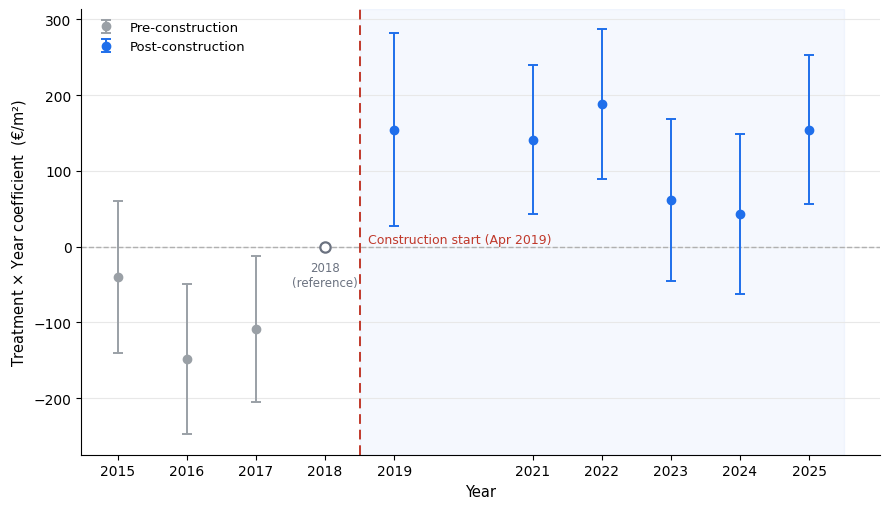

In [16]:
import numpy as np, matplotlib.pyplot as plt

# Pull from event_df if present, else use the Model 5 values
try:
    years = event_df['year'].to_numpy()
    coef  = event_df['coef'].to_numpy()
    se    = event_df['se'].to_numpy()
except NameError:
    years = np.array([2015,2016,2017,2018,2019,2021,2022,2023,2024,2025])
    coef  = np.array([-40.21,-148.86,-108.54,0,154.23,141.02,188.03,61.66,43.40,154.04])
    se    = np.array([51.35,50.49,49.36,0,64.85,50.17,50.40,54.26,53.85,50.22])

ci = 1.96*se
REF = 2018
pre, ref, post = years < REF, years == REF, years > REF
C_PRE, C_POST, C_REF = "#9aa0a6", "#1f6feb", "#6b7280"

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.axvspan(REF+0.5, years.max()+0.5, color="#1f6feb", alpha=0.045, zorder=0)
ax.axhline(0, color="#b0b0b0", lw=1.0, ls="--", zorder=1)
ax.axvline(REF+0.5, color="#c0392b", lw=1.4, ls=(0,(5,3)), zorder=2)
ax.text(REF+0.5, ax.get_ylim()[1], "  Construction start (Apr 2019)",
        color="#c0392b", fontsize=9, va="bottom", ha="left")

for mask, col, lab in [(pre, C_PRE, "Pre-construction"), (post, C_POST, "Post-construction")]:
    ax.errorbar(years[mask], coef[mask], yerr=ci[mask], fmt="o", ms=6, color=col,
                ecolor=col, elinewidth=1.4, capsize=3.5, capthick=1.4, zorder=4, label=lab)
ax.scatter(years[ref], coef[ref], s=55, facecolors="white",
           edgecolors=C_REF, linewidths=1.6, zorder=5)
ax.annotate("2018\n(reference)", (REF,0), textcoords="offset points",
            xytext=(0,-28), ha="center", fontsize=8.5, color=C_REF)

ax.set_xticks(years); ax.set_xlabel("Year", fontsize=10.5)
ax.set_ylabel(r"Treatment $\times$ Year coefficient  (€/m²)", fontsize=10.5)
ax.grid(axis="y", color="#e8e8e8", lw=0.8); ax.set_axisbelow(True)
for s in ["top","right"]: ax.spines[s].set_visible(False)
ax.legend(frameon=False, fontsize=9.5, loc="upper left")
plt.tight_layout()
plt.savefig("figure11_event_study.pdf", bbox_inches="tight")
plt.show()

BUILDING PERMITS — Montpellier (Sit@del2)
      dwellings   surface
year                     
2009     2610.0  156734.0
2010     2634.0  155715.0
2011     2751.0  181411.0
2012     2215.0  147977.0
2013     3152.0  159916.0
2014     3152.0  159916.0
2015     3192.0  191396.0
2016     3359.0  185244.0
2017     3980.0  227381.0
2018     3825.0  196726.0
2019     3367.0  163293.0

2009–2016 baseline (excl. 2014 dup): 2,845 dwellings/yr
2017–2018 average:                   3,902 dwellings/yr  (+37.2%)
2017 rank among 2009–2019: #1 of 11
Floor area peak year: 2017 (227,381 m²)


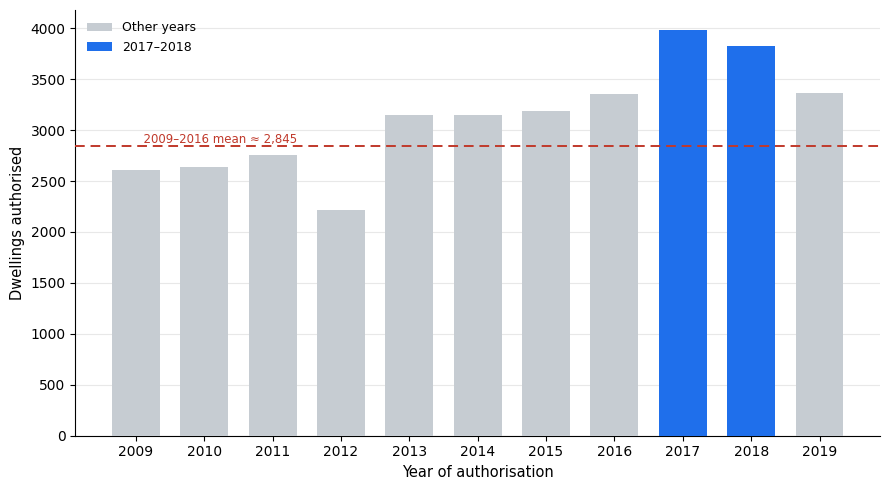

In [ ]:
# URBAN DEVELOPMENT INTENSITY — Sit@del2 building permits
# Supports the 2017–2018 supply-surge explanation for the pre-period.
# Commune-level annual authorisations (dwellings + floor area), Hérault 2009–2019.

import json

SITADEL_PATH = f"{DATA_DIR}/sitdel2-2018.geojson"   # adjust to your path

with open(SITADEL_PATH) as f:
    _gj = json.load(f)
sitadel = pd.DataFrame([ft['properties'] for ft in _gj['features']])
sitadel['year']      = sitadel['year'].astype(int)
sitadel['dwellings'] = pd.to_numeric(sitadel['total_nombre_de_logements'], errors='coerce')
sitadel['surface']   = pd.to_numeric(sitadel['total_surface_en_m2'], errors='coerce')

# --- Montpellier time series ---
mtp = (sitadel[sitadel['com_arm_name'] == 'Montpellier']
       .sort_values('year').set_index('year'))

# Wider Line 5 / Bustram corridor (commune aggregate)
CORRIDOR = ['Montpellier', 'Saint-Jean-de-Védas', 'Lavérune',
            'Clapiers', 'Castelnau-le-Lez', 'Montferrier-sur-Lez']
corridor = (sitadel[sitadel['com_arm_name'].isin(CORRIDOR)]
            .groupby('year')['dwellings'].sum())

base_years = [y for y in range(2009, 2017) if y != 2014]   # 2014 duplicates 2013 in source
baseline   = mtp.loc[base_years, 'dwellings'].mean()
p1718      = mtp.loc[[2017, 2018], 'dwellings'].mean()

print("="*60)
print("BUILDING PERMITS — Montpellier (Sit@del2)")
print("="*60)
print(mtp[['dwellings', 'surface']].to_string())
print(f"\n2009–2016 baseline (excl. 2014 dup): {baseline:,.0f} dwellings/yr")
print(f"2017–2018 average:                   {p1718:,.0f} dwellings/yr  "
      f"(+{100*(p1718/baseline-1):.1f}%)")
print(f"2017 rank among 2009–2019: "
      f"#{int((mtp['dwellings'] > mtp.loc[2017,'dwellings']).sum() + 1)} of {len(mtp)}")
print(f"Floor area peak year: {mtp['surface'].idxmax()} "
      f"({mtp['surface'].max():,.0f} m²)")

# --- Figure ---
fig, ax = plt.subplots(figsize=(9, 5))
yrs, vals = mtp.index.to_numpy(), mtp['dwellings'].to_numpy()
hot = np.isin(yrs, [2017, 2018])
ax.bar(yrs[~hot], vals[~hot], color="#c6ccd2", width=0.7, zorder=3, label="Other years")
ax.bar(yrs[hot],  vals[hot],  color="#1f6feb", width=0.7, zorder=3, label="2017–2018")
ax.axhline(baseline, color="#c0392b", ls=(0,(5,3)), lw=1.4, zorder=4)
ax.text(yrs.min(), baseline, f"  2009–2016 mean ≈ {baseline:,.0f}",
        color="#c0392b", fontsize=8.5, va="bottom", ha="left")
ax.set_xticks(yrs); ax.set_xlabel("Year of authorisation", fontsize=10.5)
ax.set_ylabel("Dwellings authorised", fontsize=10.5)
ax.grid(axis="y", color="#e8e8e8", lw=0.8, zorder=0); ax.set_axisbelow(True)
for s in ["top","right"]: ax.spines[s].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("permits_montpellier.pdf", bbox_inches="tight")
plt.show()

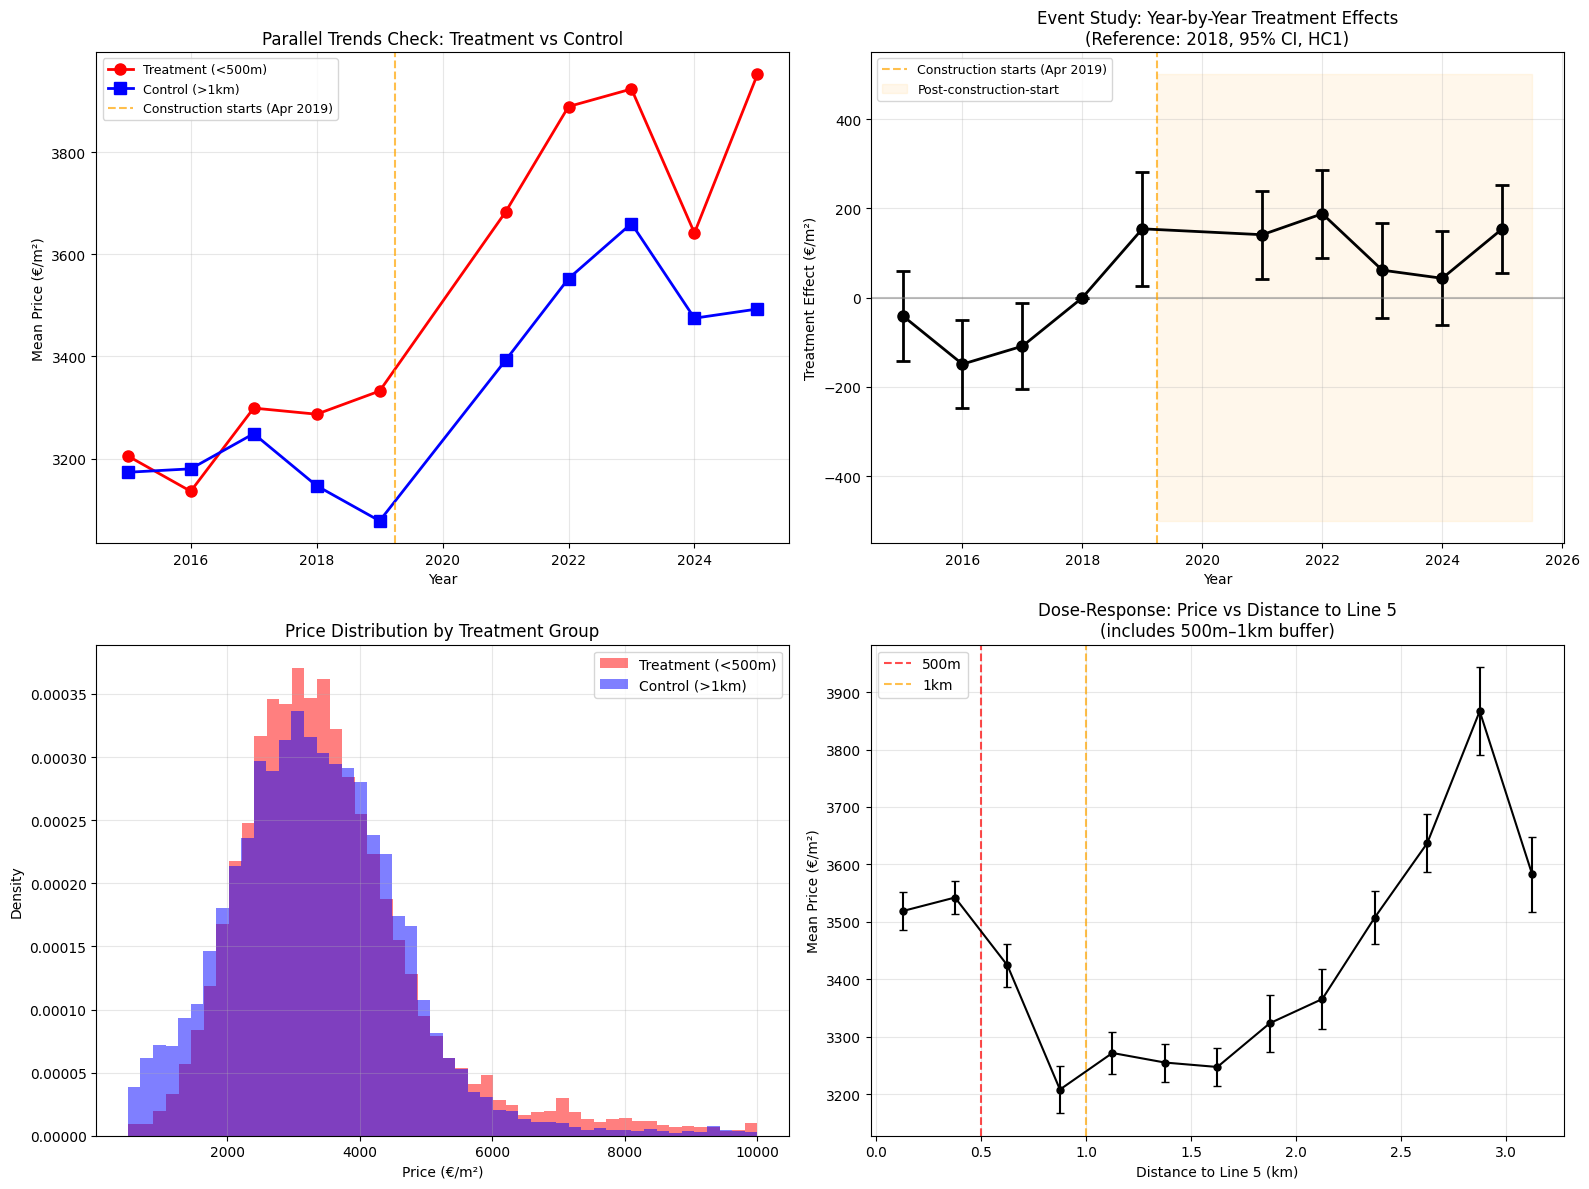


NOTES:
- Headline SE: HC1 robust. Clustered (5 PCs) reported as Model 3-cl robustness.
- Construction-start cutoff: April 2019 (physical works began)
- 2020 dropped (DVF data gap)
- Event study reference year: 2018
- Postal codes: 34000, 34070, 34080, 34090, 34170
- Outliers removed: price/m² < €500 or > €10,000


In [ ]:

# DID PART 4: VISUALIZATIONS

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

annual_means = df_did_clean.groupby(['year', 'treatment'])['price_m2'].mean().unstack()
annual_means.columns = ['Control (>1km)', 'Treatment (<500m)']

axes[0, 0].plot(annual_means.index, annual_means['Treatment (<500m)'],
                'ro-', linewidth=2, markersize=8, label='Treatment (<500m)')
axes[0, 0].plot(annual_means.index, annual_means['Control (>1km)'],
                'bs-', linewidth=2, markersize=8, label='Control (>1km)')
axes[0, 0].axvline(x=2019.25, color='orange', linestyle='--', alpha=0.7,
                    label='Construction starts (Apr 2019)')
axes[0, 0].set_xlabel('Year'); axes[0, 0].set_ylabel('Mean Price (€/m²)')
axes[0, 0].set_title('Parallel Trends Check: Treatment vs Control')
axes[0, 0].legend(fontsize=9); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].errorbar(event_df['year'], event_df['coef'],
                     yerr=1.96 * event_df['se'],
                     fmt='ko-', linewidth=2, markersize=8, capsize=5, capthick=2)
axes[0, 1].axhline(y=0, color='grey', alpha=0.5)
axes[0, 1].axvline(x=2019.25, color='orange', linestyle='--', alpha=0.7,
                    label='Construction starts (Apr 2019)')
axes[0, 1].fill_betweenx([-500, 500], 2019.25, 2025.5, alpha=0.08, color='orange',
                           label='Post-construction-start')
axes[0, 1].set_xlabel('Year'); axes[0, 1].set_ylabel('Treatment Effect (€/m²)')
axes[0, 1].set_title(f'Event Study: Year-by-Year Treatment Effects\n'
                      f'(Reference: {REF_YEAR}, 95% CI, HC1)')
axes[0, 1].legend(fontsize=9); axes[0, 1].grid(True, alpha=0.3)

for grp, label, color in [(1, 'Treatment (<500m)', 'red'), (0, 'Control (>1km)', 'blue')]:
    subset = df_did_clean[df_did_clean['treatment'] == grp]['price_m2']
    axes[1, 0].hist(subset, bins=50, alpha=0.5, color=color, label=label, density=True)
axes[1, 0].set_xlabel('Price (€/m²)'); axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Price Distribution by Treatment Group')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

distance_bins = np.arange(0, 3.5, 0.25)
df_did['dist_bin'] = pd.cut(df_did['distance_line5_km'], bins=distance_bins)
dose_response = df_did.groupby('dist_bin', observed=True).agg(
    mean_price=('price_m2', 'mean'),
    n=('price_m2', 'count'),
    se=('price_m2', lambda x: x.std() / np.sqrt(len(x)))
).dropna()

bin_centers = [interval.mid for interval in dose_response.index]
axes[1, 1].errorbar(bin_centers, dose_response['mean_price'],
                     yerr=1.96 * dose_response['se'],
                     fmt='ko-', markersize=5, capsize=3)
axes[1, 1].axvline(x=0.5, color='r', linestyle='--', alpha=0.7, label='500m')
axes[1, 1].axvline(x=1.0, color='orange', linestyle='--', alpha=0.7, label='1km')
axes[1, 1].set_xlabel('Distance to Line 5 (km)'); axes[1, 1].set_ylabel('Mean Price (€/m²)')
axes[1, 1].set_title('Dose-Response: Price vs Distance to Line 5\n(includes 500m–1km buffer)')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print("\n" + "=" * 70)
print("NOTES:")
print("- Headline SE: HC1 robust. Clustered (5 PCs) reported as Model 3-cl robustness.")
print("- Construction-start cutoff: April 2019 (physical works began)")
print("- 2020 dropped (DVF data gap)")
print(f"- Event study reference year: {REF_YEAR}")
print("- Postal codes: 34000, 34070, 34080, 34090, 34170")
print("- Outliers removed: price/m² < €500 or > €10,000")
print("=" * 70)

In [ ]:

# DID PART 5: SUMMARY TABLE 

print("\n" + "=" * 90)
print("SUMMARY OF DiD RESULTS")
print("=" * 90)
print(f"{'Model':<48} {'Coef (€/m²)':>12} {'SE':>10} {'p-value':>10} {'Sig':>5}")
print("-" * 90)

results = [
    ("M1: Proximity premium",
     model1.params['treatment'], model1.bse['treatment'], model1.pvalues['treatment']),
    ("M2: Construction-start DiD (no controls)",
     model2.params['did_construction_start'],
     model2.bse['did_construction_start'],
     model2.pvalues['did_construction_start']),
    ("M3: Construction-start DiD (controls+FE, HC1)",
     model3.params['did_construction_start'],
     model3.bse['did_construction_start'],
     model3.pvalues['did_construction_start']),
    ("M3-cl: Same as M3 with clustered SE",
     model3_cl.params['did_construction_start'],
     model3_cl.bse['did_construction_start'],
     model3_cl.pvalues['did_construction_start']),
    ("M3b: Construction-start DiD (log, ×100=%)",
     model3b.params['did_construction_start']*100,
     model3b.bse['did_construction_start']*100,
     model3b.pvalues['did_construction_start']),
    ("M4: Construction-advanced DiD 2022+ (ctrl+FE)",
     model4.params['did_construction_advanced'],
     model4.bse['did_construction_advanced'],
     model4.pvalues['did_construction_advanced']),
]

for name, coef, se, pval in results:
    sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
    print(f"{name:<48} {coef:>12.2f} {se:>10.2f} {pval:>10.4f} {sig:>5}")

print("-" * 90)
print(f"\nEvent study coefficients (reference = {REF_YEAR}):")
for _, row in event_df.iterrows():
    yr = int(row['year'])
    sig = '***' if row['pval'] < 0.01 else ('**' if row['pval'] < 0.05 else ('*' if row['pval'] < 0.1 else ''))
    yr_label = f"  {yr} {'(ref)' if yr == REF_YEAR else ''}"
    pval_str = f"{row['pval']:.4f}" if not np.isnan(row['pval']) else "  ref"
    print(f"{yr_label:<40} {row['coef']:>12.2f} {row['se']:>10.2f} {pval_str:>10} {sig:>5}")

print("\n" + "=" * 90)
print("INTERPRETATION:")
print("- Main DiD captures the CONSTRUCTION-CREDIBILITY break (Apr 2019)")
print("  — when physical works began, not the political announcements of 2009/2016")
print("- M3-cl shows that the coefficient is stable under clustered SE; HC1 is the")
print("  headline because 5 postal-code clusters is too few for cluster inference")
print("- M3b gives percentage interpretation; M4 tests whether the effect intensifies")
print("  as construction progresses; event study validates parallel pre-trends")
print("=" * 90)


SUMMARY OF DiD RESULTS
Model                                             Coef (€/m²)         SE    p-value   Sig
------------------------------------------------------------------------------------------
M1: Proximity premium                                  185.13      13.16     0.0000   ***
M2: Construction-start DiD (no controls)               238.88      26.28     0.0000   ***
M3: Construction-start DiD (controls+FE, HC1)          173.62      23.75     0.0000   ***
M3-cl: Same as M3 with clustered SE                    173.62      43.18     0.0001   ***
M3b: Construction-start DiD (log, ×100=%)                4.58       0.69     0.0000   ***
M4: Construction-advanced DiD 2022+ (ctrl+FE)          132.40      24.32     0.0000   ***
------------------------------------------------------------------------------------------

Event study coefficients (reference = 2018):
  2015                                         -40.21      51.35     0.4336      
  2016                              

In [ ]:

# Conley spatial HAC standard errors — helper

# Implements Conley (1999) spatial HAC SEs with a Bartlett kernel.
# Standard alternative to cluster SE when the treatment is geographic and observations have point coordinates. 
# It should avoid the small-cluster problem entirely (5 postal codes is too few).
#
# Math: V(β) = (X'X)^-1 · Ω · (X'X)^-1
#       Ω    = X' · diag(e) · K · diag(e) · X
#       K_ij = max(0, 1 - dist_ij / cutoff_km)  (Bartlett, K_ii = 1)
#
# Implementation: cKDTree to find pairs within cutoff, then build a sparse symmetric kernel matrix. Memory ~ O(N · avg_neighbors).

from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix

def conley_se(model, lat, lon, cutoff_km=0.5, verbose=True):
    """
    Conley spatial HAC standard errors with Bartlett kernel.

    Parameters
    ----------
    model     : fitted statsmodels OLS results
    lat, lon  : 1-D numpy arrays of length N (the regression sample)
    cutoff_km : Bartlett cutoff in kilometres (default 0.5)

    Returns
    -------
    pandas Series of standard errors (same index as model.params).
    """
    X = np.asarray(model.model.exog)
    e = np.asarray(model.resid)
    N, K = X.shape

    if N != len(lat) or N != len(lon):
        raise ValueError(
            f"lat/lon length ({len(lat)}/{len(lon)}) does not match "
            f"regression sample ({N}). Check df.loc[model.model.data.row_labels] alignment."
        )

    mean_lat = np.radians(np.mean(lat))
    xy = np.column_stack([
        lat * 111.32,
        lon * 111.32 * np.cos(mean_lat)
    ])

    tree = cKDTree(xy)
    pairs = tree.query_pairs(cutoff_km, output_type='ndarray')

    if len(pairs) == 0:
        if verbose:
            print(f"  Conley: no pairs within {cutoff_km} km — returning HC1-like SEs.")
        rows = cols = np.arange(N)
        vals = np.ones(N)
    else:
        d_ij = np.linalg.norm(xy[pairs[:, 0]] - xy[pairs[:, 1]], axis=1)
        w_ij = np.maximum(0.0, 1.0 - d_ij / cutoff_km)
        # Symmetric: include (i,j) and (j,i); diagonal = 1
        rows = np.concatenate([np.arange(N), pairs[:, 0], pairs[:, 1]])
        cols = np.concatenate([np.arange(N), pairs[:, 1], pairs[:, 0]])
        vals = np.concatenate([np.ones(N), w_ij, w_ij])

    W = csr_matrix((vals, (rows, cols)), shape=(N, N))

    if verbose:
        n_pairs = len(pairs)
        avg_neighbors = 2 * n_pairs / N if N > 0 else 0
        print(f"  Conley: N={N:,}, pairs<{cutoff_km}km = {n_pairs:,} "
              f"(avg {avg_neighbors:.0f} neighbors per obs)")

    G = X * e[:, None]               # N × K
    omega = G.T @ (W @ G)            # K × K
    bread = np.linalg.inv(X.T @ X)
    var_beta = bread @ omega @ bread
    se = np.sqrt(np.maximum(np.diag(var_beta), 0.0))
    return pd.Series(se, index=model.params.index)


def report_conley(model, df_sample, coef_name, cutoff_km=0.5, label="Conley SE"):
    """Wrap conley_se + pretty-print one coefficient with t-test."""
    se_conley = conley_se(model, df_sample['latitude'].values,
                          df_sample['longitude'].values, cutoff_km=cutoff_km)
    coef = model.params[coef_name]
    se   = se_conley[coef_name]
    t    = coef / se
    # Two-sided p from normal approx (large N)
    from scipy.stats import norm
    pval = 2 * (1 - norm.cdf(abs(t)))
    stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else "n.s."
    print(f"\n→ {label} (cutoff = {cutoff_km} km): "
          f"€{coef:.2f}/m²  (SE={se:.2f}, p={pval:.4f}) {stars}")
    return coef, se, pval


In [ ]:

# LINE 5 — ROBUSTNESS BATTERY

# (a) Finer geography:    grid_id FE + grid_id-clustered SE  (~50-150 clusters)
# (b) Spatial HAC:        Conley SE with 0.5 km Bartlett cutoff
# (c) Type heterogeneity: M3 separately on apartments and houses

# Need grid_id in df_did_clean (propagated from df_filtered → df_housing → df_did)
if 'grid_id' not in df_did_clean.columns:
    raise RuntimeError("grid_id missing in df_did_clean — check that the grid cell ran")

n_grid = df_did_clean['grid_id'].nunique()
print(f"Number of grid cells in DiD sample: {n_grid:,}")
n_iris = df_did_clean['code_iris'].nunique() if 'code_iris' in df_did_clean.columns else 0
if n_iris:
    print(f"Number of IRIS in DiD sample: {n_iris:,}")


# Robustness 1: grid_id FE + grid-clustered SE

section("LINE 5 — M3-grid: FE & cluster at 500m grid cell level")

# Use grid_id as both FE and cluster. Drop postal-code dummies because
# they are absorbed by the finer grid FE.
grid_dummies = pd.get_dummies(df_did_clean['grid_id'], prefix='g', drop_first=True, dtype=int)
X3_grid = sm.add_constant(pd.concat([
    df_did_clean[['treatment', 'post_construction_start', 'did_construction_start',
                   'year', 'is_apartment', 'log_surface']],
    grid_dummies, quarter_dummies
], axis=1))

cluster_grid = df_did_clean['grid_id']
model3_grid = run_ols(df_did_clean['price_m2'], X3_grid,
                       cov='cluster', groups=cluster_grid,
                       model_name=f"Model 3-grid: FE+cluster on {n_grid} grid cells")
print_did_result(model3_grid, 'did_construction_start',
                 "Construction-start effect (grid FE & cluster)")

# Same in log
section("LINE 5 — M3-grid-log")
model3_grid_log = run_ols(df_did_clean['log_price_m2'], X3_grid,
                           cov='cluster', groups=cluster_grid,
                           model_name="Model 3-grid-log: log(price/m²)")
coef = model3_grid_log.params['did_construction_start']
pval = model3_grid_log.pvalues['did_construction_start']
print(f"\n→ Construction-start effect (log, grid FE+cluster): "
      f"{coef:.4f} ≈ {coef*100:.2f}% (p={pval:.4f})")


# Robustness 2: Conley spatial HAC standard errors

section("LINE 5 — M3-conley: Conley spatial HAC SE on M3 specification")

# Reuse exactly the M3 design matrix (postal-code FE, HC1 fitted earlier)
# but recompute SE with Conley.
print("Computing Conley SE on M3 (postal-code FE, level spec):")
report_conley(model3, df_did_clean, 'did_construction_start',
              cutoff_km=0.5, label="M3-conley (postal FE)")
report_conley(model3, df_did_clean, 'did_construction_start',
              cutoff_km=1.0, label="M3-conley (postal FE)")

print("\nComputing Conley SE on M3-grid (grid FE):")
report_conley(model3_grid, df_did_clean, 'did_construction_start',
              cutoff_km=0.5, label="M3-grid-conley")


# Robustness 3: Apartments vs Houses (separate samples)

type_results = {}
for ptype, label_short in [('Appartement', 'Apt'), ('Maison', 'House')]:
    section(f"LINE 5 — M3 split: {ptype}s only")
    sub = df_did_clean[df_did_clean['type_local'] == ptype].copy()
    n_t = (sub['treatment'] == 1).sum()
    n_c = (sub['treatment'] == 0).sum()
    print(f"  Sample: {len(sub):,}  (treated={n_t:,}, control={n_c:,})")
    if n_t < 100 or n_c < 100:
        print(f"   Skipped: too few obs in one group")
        continue

    sub_postal = pd.get_dummies(sub['code_postal'], prefix='cp', drop_first=True, dtype=int)
    sub_quarter = pd.get_dummies(sub['quarter'],     prefix='Q',  drop_first=True, dtype=int)
    X_sub = sm.add_constant(pd.concat([
        sub[['treatment', 'post_construction_start', 'did_construction_start',
             'year', 'log_surface']],   # is_apartment dropped (constant in subsample)
        sub_postal, sub_quarter
    ], axis=1))

    m_lvl = run_ols(sub['price_m2'], X_sub, cov='HC1',
                     model_name=f"M3 — {ptype}s, level")
    print_did_result(m_lvl, 'did_construction_start',
                     f"Construction-start effect ({ptype}s, level)")

    m_log = run_ols(np.log(sub['price_m2']), X_sub, cov='HC1',
                     model_name=f"M3 — {ptype}s, log")
    c_log = m_log.params['did_construction_start']
    p_log = m_log.pvalues['did_construction_start']
    s = "***" if p_log < 0.01 else "**" if p_log < 0.05 else "*" if p_log < 0.1 else "n.s."
    print(f"\n→ Construction-start effect ({ptype}s, log): "
          f"{c_log:.4f} ≈ {c_log*100:.2f}%  (p={p_log:.4f}) {s}")

    type_results[ptype] = (m_lvl, m_log, sub)

# Summary across types
print("\n" + "=" * 80)
print("LINE 5 — TYPE HETEROGENEITY SUMMARY")
print("=" * 80)
print(f"{'Sample':<22} {'N':>8} {'Coef (€/m²)':>13} {'SE':>9} {'p':>9}  "
      f"{'Coef (%)':>10} {'p (log)':>9}")
print("-" * 92)
for ptype, (m_lvl, m_log, sub) in type_results.items():
    print(f"{ptype:<22} {len(sub):>8,} "
          f"{m_lvl.params['did_construction_start']:>13.2f} "
          f"{m_lvl.bse['did_construction_start']:>9.2f} "
          f"{m_lvl.pvalues['did_construction_start']:>9.4f}  "
          f"{m_log.params['did_construction_start']*100:>10.2f} "
          f"{m_log.pvalues['did_construction_start']:>9.4f}")
print("-" * 92)
print("Pooled M3 for reference:  "
      f"€{model3.params['did_construction_start']:.2f}/m²  "
      f"({model3b.params['did_construction_start']*100:.2f}%)")
print("=" * 80)


Number of grid cells in DiD sample: 247

############################################################
LINE 5 — M3-grid: FE & cluster at 500m grid cell level
############################################################

Model 3-grid: FE+cluster on 247 grid cells
                                Coef.      Std.Err.           z          P>|z|        [0.025        0.975]
const                   -62000.120340  12859.649707   -4.821292   1.426317e-06 -87204.570619 -36795.670060
treatment                 1091.245663     60.925134   17.911256   9.633707e-72    971.834595   1210.656731
post_construction_start    247.134016     46.054983    5.366065   8.047309e-08    156.867909    337.400123
did_construction_start      95.472469     69.195668    1.379746   1.676648e-01    -40.148549    231.093487
year                        33.526696      6.366478    5.266130   1.393299e-07     21.048629     46.004763
is_apartment             -1026.435313     69.817456  -14.701700   6.286118e-49  -1163.275011   -

/opt/anaconda3/envs/tf-metal/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 255, but rank is 8
  warnings.warn('covariance of constraints does not have full '



Model 3-grid-log: log(price/m²)
                             Coef.  Std.Err.           z          P>|z|     [0.025    0.975]
const                   -13.635791  3.663022   -3.722552   1.972195e-04 -20.815183 -6.456398
treatment                 0.273032  0.020242   13.488330   1.832031e-41   0.233359  0.312706
post_construction_start   0.087657  0.014982    5.850942   4.887980e-09   0.058294  0.117021
did_construction_start    0.015230  0.019829    0.768056   4.424539e-01  -0.023634  0.054094
year                      0.011135  0.001811    6.148214   7.836011e-10   0.007586  0.014685
is_apartment             -0.317078  0.024623  -12.877252   6.044951e-38  -0.365338 -0.268817
log_surface              -0.211081  0.012250  -17.231103   1.551652e-66  -0.235091 -0.187072
g_9702_622                0.405138  0.015576   26.011143  3.704773e-149   0.374611  0.435666
g_9702_624                0.147194  0.014693   10.017678   1.274628e-23   0.118396  0.175993
g_9703_621                0.359512  0

/opt/anaconda3/envs/tf-metal/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 255, but rank is 8
  warnings.warn('covariance of constraints does not have full '


  Conley: N=47,306, pairs<0.5km = 28,745,767 (avg 1215 neighbors per obs)

→ M3-conley (postal FE) (cutoff = 0.5 km): €173.62/m²  (SE=70.39, p=0.0136) **
  Conley: N=47,306, pairs<1.0km = 85,040,585 (avg 3595 neighbors per obs)

→ M3-conley (postal FE) (cutoff = 1.0 km): €173.62/m²  (SE=79.73, p=0.0294) **

Computing Conley SE on M3-grid (grid FE):
  Conley: N=47,306, pairs<0.5km = 28,745,767 (avg 1215 neighbors per obs)

→ M3-grid-conley (cutoff = 0.5 km): €95.47/m²  (SE=62.41, p=0.1261) n.s.

############################################################
LINE 5 — M3 split: Appartements only
############################################################
  Sample: 41,654  (treated=14,946, control=26,708)

M3 — Appartements, level
                                Coef.     Std.Err.          z         P>|z|        [0.025        0.975]
const                   -41561.697585  8010.661271  -5.188298  2.122248e-07 -57262.305170 -25861.090001
treatment                 -169.655724    18.546829  -9.1

In [ ]:

# BUSTRAM A — SETUP, STOPS & FILTERED DATASETS


import json
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import matplotlib.pyplot as plt

DATA_DIR = '/Users/castetpaul/Downloads/MemoireDATA'

# Phase 1 stops — list-mean centroid
with open(f'{DATA_DIR}/MMM_MMM_BustramArrets.json', 'r') as f:
    arrets_data = json.load(f)

stops_p1_acc = {}
for feat in arrets_data['features']:
    name = feat['properties']['description']
    lon, lat = feat['geometry']['coordinates']
    stops_p1_acc.setdefault(name, {'lats': [], 'lons': []})
    stops_p1_acc[name]['lats'].append(lat)
    stops_p1_acc[name]['lons'].append(lon)

stops_p1 = {n: (np.mean(d['lats']), np.mean(d['lons']))
            for n, d in stops_p1_acc.items()}
p1_stops = np.array(list(stops_p1.values()))
print(f"Phase 1 — existing stops: {len(p1_stops)}")
for name, (lat, lon) in stops_p1.items():
    n_obs = len(stops_p1_acc[name]['lats'])
    print(f"  {name}: ({lat:.4f}, {lon:.4f})  [{n_obs} platform(s) averaged]")

# Phase 2 stops — dedup by description if present
with open(f'{DATA_DIR}/MMM_MMM_ProjetReseauBustramArrets.json', 'r') as f:
    arrets_projet = json.load(f)

stops_p2_acc = {}
p2_communes_lookup = {}
for feat in arrets_projet['features']:
    if feat['properties'].get('num_ligne') != 'bustram 1':
        continue
    desc    = feat['properties'].get('description') or feat['properties'].get('nom')
    commune = feat['properties'].get('commune', 'unknown')
    coords  = feat['geometry']['coordinates']
    lat, lon = coords[1], coords[0]
    key = desc if desc else f"{lat:.4f}_{lon:.4f}"
    stops_p2_acc.setdefault(key, {'lats': [], 'lons': []})
    stops_p2_acc[key]['lats'].append(lat)
    stops_p2_acc[key]['lons'].append(lon)
    p2_communes_lookup[key] = commune

stops_p2 = {k: (np.mean(d['lats']), np.mean(d['lons']))
            for k, d in stops_p2_acc.items()}
p2_stops = np.array(list(stops_p2.values()))
p2_communes = sorted(set(p2_communes_lookup.values()))
print(f"\nPhase 2 — extension stops: {len(p2_stops)}")
print(f"Communes covered by extension: {p2_communes}")
for key, (lat, lon) in stops_p2.items():
    print(f"  {p2_communes_lookup[key]} / {key}: ({lat:.4f}, {lon:.4f})")

# Distance function
def calc_dist_to_stops(df_input, stops_array):
    coords = df_input[['latitude', 'longitude']].values
    mean_lat = np.radians(coords[:, 0].mean())
    prop_xy = np.column_stack([
        coords[:, 0] * 111.32,
        coords[:, 1] * 111.32 * np.cos(mean_lat)
    ])
    stop_xy = np.column_stack([
        stops_array[:, 0] * 111.32,
        stops_array[:, 1] * 111.32 * np.cos(mean_lat)
    ])
    return cdist(prop_xy, stop_xy, metric='euclidean').min(axis=1)

P1_POSTAL_CODES = [34000, 34070, 34080, 34090, 34170]
COMMUNE_TO_CP = {
    'Castelnau-le-Lez': 34170,
    'Le Crès':         34920,
    'Vendargues':      34740,
    'Castries':        34160,
}
P2_POSTAL_CODES = sorted({COMMUNE_TO_CP[c] for c in p2_communes if c in COMMUNE_TO_CP})
unmatched = [c for c in p2_communes if c not in COMMUNE_TO_CP]
if unmatched:
    print(f" Communes not in COMMUNE_TO_CP: {unmatched} — ignored")
if not P2_POSTAL_CODES:
    print(" Falling back to default Phase 2 codes [34170, 34160]")
    P2_POSTAL_CODES = [34170, 34160]
print(f"\nPhase 2 postal codes (derived): {P2_POSTAL_CODES}")

# code_postal already pinned to Int64 in Part 1 — no re-cast needed.

def filter_corridor(df_src, postal_codes):
    m = (
        df_src['code_postal'].isin(postal_codes) &
        df_src['valeur_fonciere'].notna() &
        df_src['longitude'].notna() &
        df_src['latitude'].notna() &
        df_src['surface_reelle_bati'].notna() &
        (df_src['surface_reelle_bati'] > 0)
    )
    if 'nature_mutation' in df_src.columns:
        m &= (df_src['nature_mutation'] == 'Vente')
    if 'type_local' in df_src.columns:
        m &= df_src['type_local'].isin(['Appartement', 'Maison'])
    out = df_src[m].copy()
    if 'year' not in out.columns:
        out['year'] = out['date_mutation'].dt.year
    if 'month' not in out.columns:
        out['month'] = out['date_mutation'].dt.month
    if 'year_month' not in out.columns:
        out['year_month'] = out['date_mutation'].dt.to_period('M')
    out['price_m2'] = out['valeur_fonciere'] / out['surface_reelle_bati']
    out = out[(out['price_m2'] >= 500) & (out['price_m2'] <= 10_000)].copy()
    out = out[out['year'] != 2020].copy()
    return out

# Phase 1 dataset + 2 km corridor restriction + Line 5 control
df_p1 = filter_corridor(df, P1_POSTAL_CODES)
df_p1['dist_p1_km']      = calc_dist_to_stops(df_p1, p1_stops)

# CHANGE vs V8: restrict corridor to ≤ 2 km from any Phase 1 stop.
# In V8 the postal-code corridor (5 PCs) was much larger than the BHNS line
# itself, leading to a 12:1 control:treatment imbalance and a suspiciously
# high proximity premium (€419/m² vs Line 5's €185/m²). Tightening to 2 km
# of the line gives a balanced sample.
N_PRE_2KM = len(df_p1)
CORRIDOR_RADIUS_KM = 2.0
df_p1 = df_p1[df_p1['dist_p1_km'] <= CORRIDOR_RADIUS_KM].copy()
print(f"\nPhase 1: {N_PRE_2KM:,} → {len(df_p1):,} obs after restricting to "
      f"≤ {CORRIDOR_RADIUS_KM} km from any Phase 1 stop")

df_p1['dist_line5_km']   = calc_dist_to_stops(df_p1, line5_array)
df_p1['near_line5_500m'] = (df_p1['dist_line5_km'] < 0.5).astype(int)
df_p1 = add_grid_id(df_p1, grid_km=0.5)

print(f"\n{'=' * 60}\nPHASE 1 CORRIDOR\n{'=' * 60}")
print(f"Postal codes: {P1_POSTAL_CODES}")
print(f"Transactions: {len(df_p1):,}")
print(f"\nDistance to nearest Phase 1 stop:")
print(df_p1['dist_p1_km'].describe().round(3))
print(f"\nDistance to nearest Line 5 stop (covariate):")
print(df_p1['dist_line5_km'].describe().round(3))
print(f"  Properties also <500m from Line 5: {df_p1['near_line5_500m'].sum():,} "
      f"({df_p1['near_line5_500m'].mean()*100:.1f}%)")
print(f"\nTransactions by year:")
print(df_p1['year'].value_counts().sort_index())

# Phase 2 dataset + Line 5 control
df_p2 = filter_corridor(df, P2_POSTAL_CODES)
df_p2['dist_p2_km']      = calc_dist_to_stops(df_p2, p2_stops)
df_p2['dist_line5_km']   = calc_dist_to_stops(df_p2, line5_array)
df_p2['near_line5_500m'] = (df_p2['dist_line5_km'] < 0.5).astype(int)
df_p2 = add_grid_id(df_p2, grid_km=0.5)

print(f"\n{'=' * 60}\nPHASE 2 CORRIDOR (EXTENSION)\n{'=' * 60}")
print(f"Postal codes: {P2_POSTAL_CODES}")
print(f"Transactions: {len(df_p2):,}")
print(f"\nDistance to nearest Phase 2 stop:")
print(df_p2['dist_p2_km'].describe().round(3))
print(f"\nDistance to nearest Line 5 stop:")
print(df_p2['dist_line5_km'].describe().round(3))
print(f"  Properties also <500m from Line 5: {df_p2['near_line5_500m'].sum():,} "
      f"({df_p2['near_line5_500m'].mean()*100:.1f}%)")
print(f"\nTransactions by year:")
print(df_p2['year'].value_counts().sort_index())

Phase 1 — existing stops: 8
  Place de l'Europe: (43.6070, 3.8927)  [1 platform(s) averaged]
  Pont Juvénal: (43.6062, 3.8981)  [2 platform(s) averaged]
  Paul Painlevé: (43.6100, 3.8995)  [2 platform(s) averaged]
  Pinville: (43.6140, 3.9062)  [2 platform(s) averaged]
  Alfred Nobel: (43.6160, 3.9100)  [2 platform(s) averaged]
  Eurêka: (43.6194, 3.9144)  [2 platform(s) averaged]
  Verchant: (43.6231, 3.9183)  [2 platform(s) averaged]
  Notre-Dame de Sablassou: (43.6335, 3.9222)  [2 platform(s) averaged]

Phase 2 — extension stops: 21
Communes covered by extension: ['Castelnau-le-Lez', 'Castries', 'Le Crès', 'Vendargues']
  Castelnau-le-Lez / 43.6365_3.9273: (43.6365, 3.9273)
  Le Crès / 43.6391_3.9344: (43.6391, 3.9344)
  Le Crès / 43.6417_3.9426: (43.6417, 3.9426)
  Vendargues / 43.6448_3.9493: (43.6448, 3.9493)
  Vendargues / 43.6485_3.9537: (43.6485, 3.9537)
  Vendargues / 43.6532_3.9597: (43.6532, 3.9597)
  Vendargues / 43.6580_3.9629: (43.6580, 3.9629)
  Vendargues / 43.6607_3.9

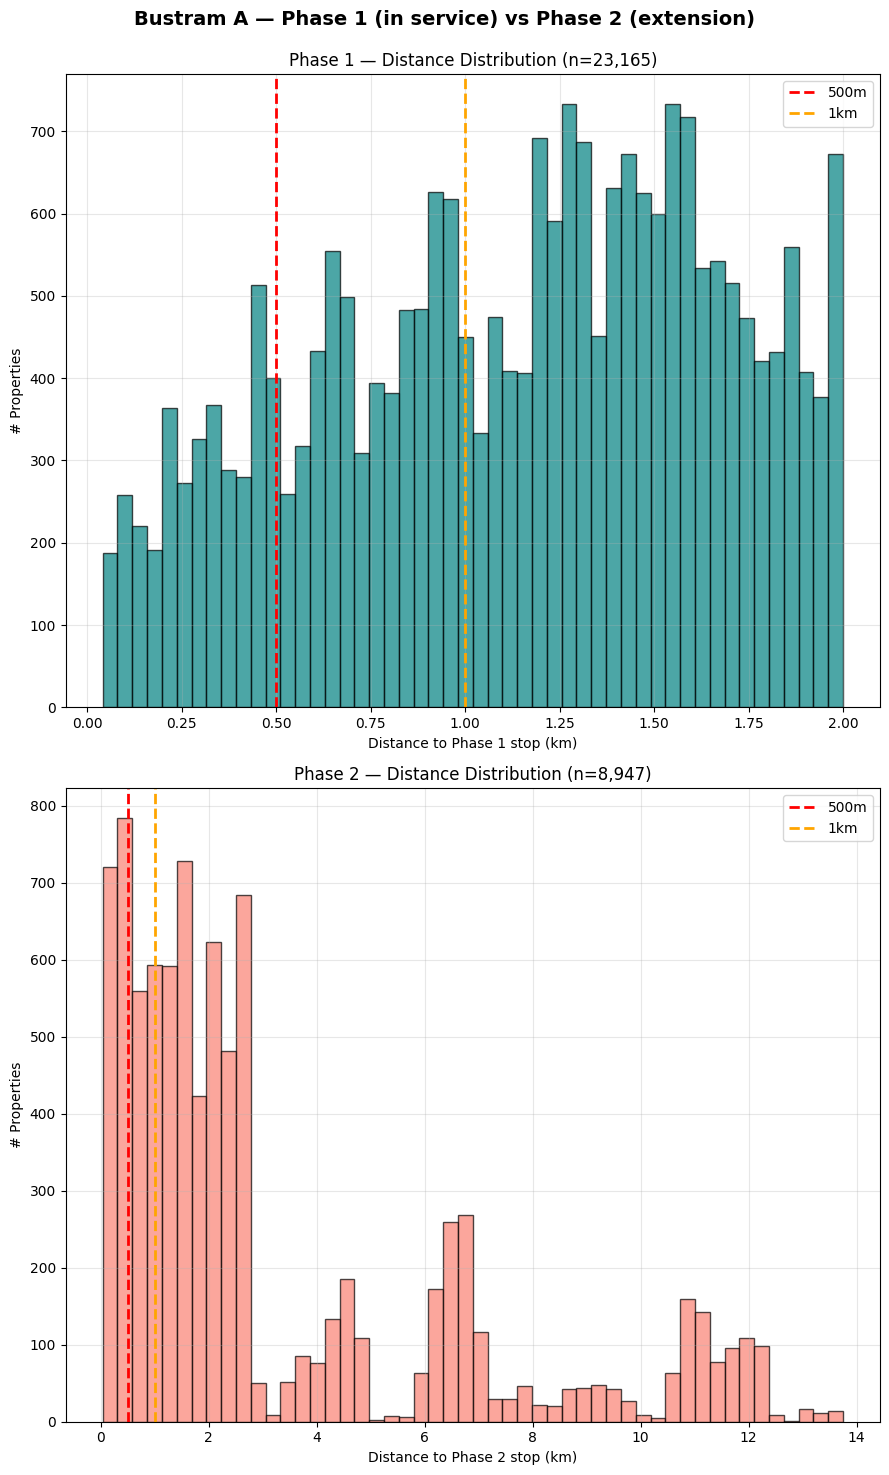

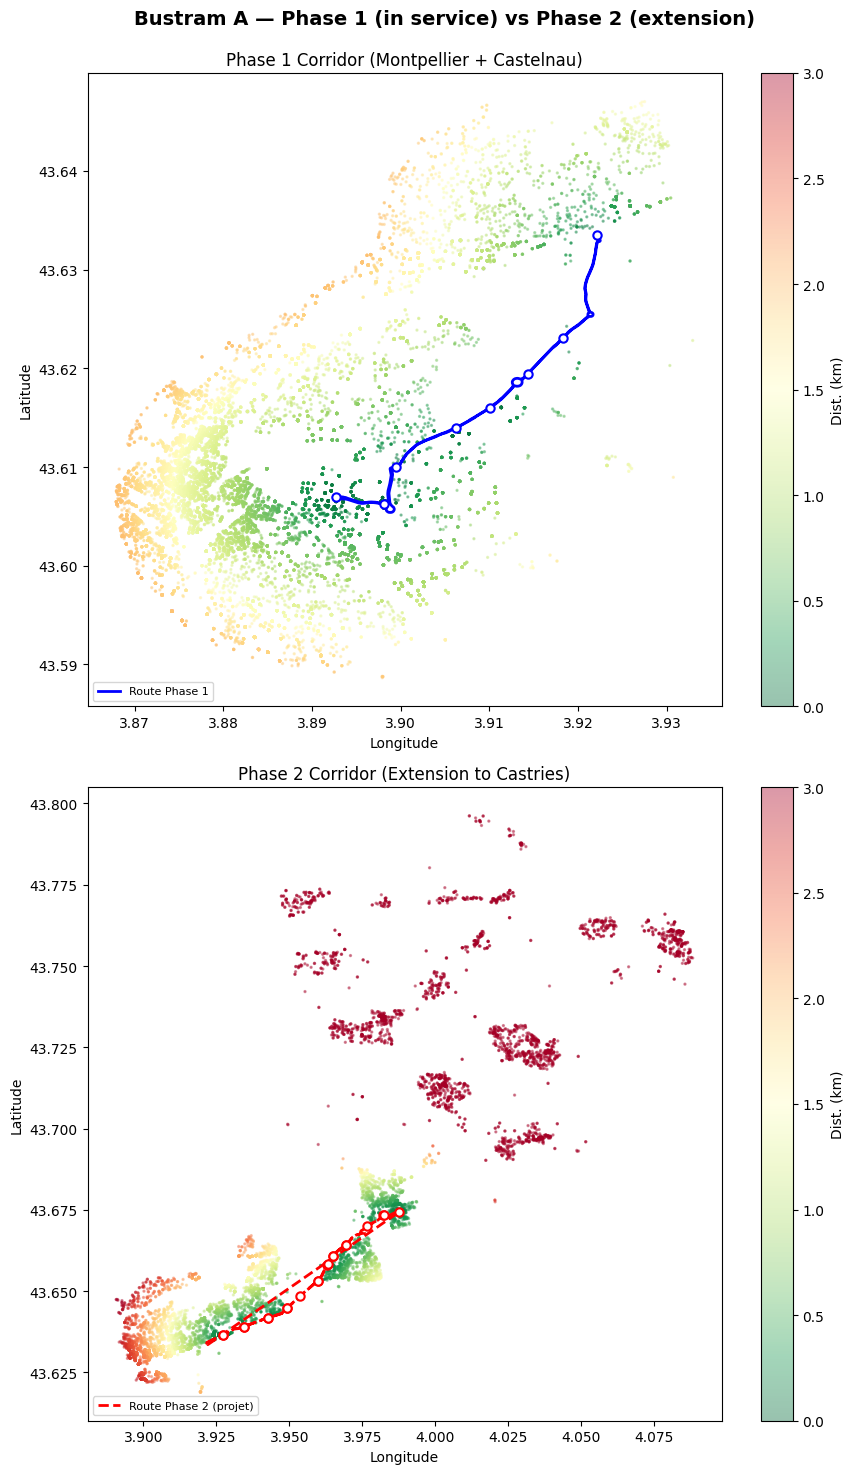

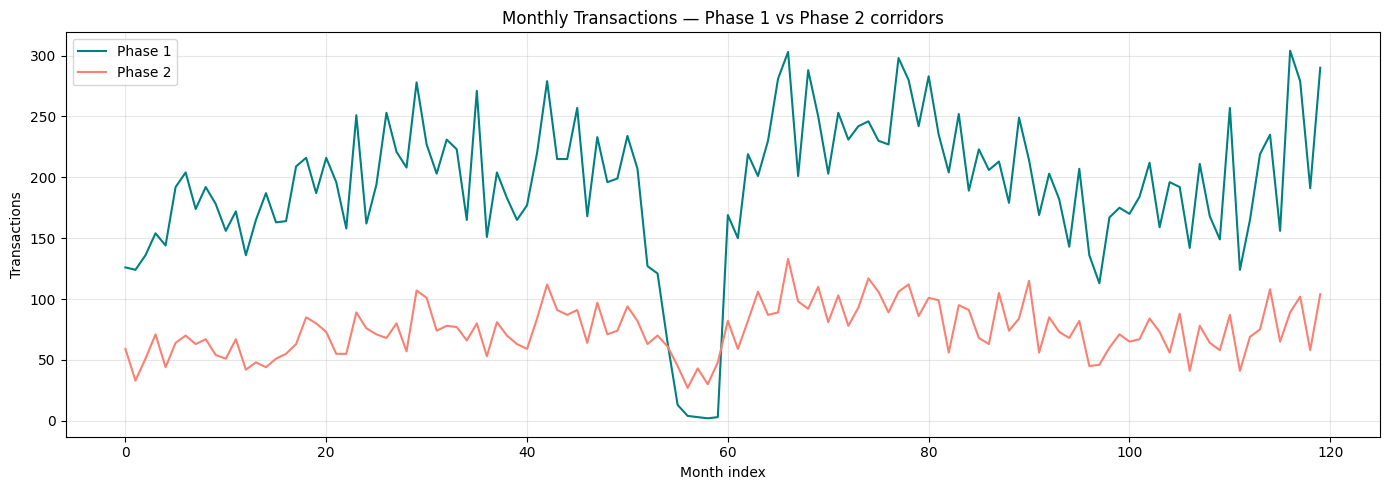

In [ ]:

# BUSTRAM A — VISUALISATIONS (BOTH CORRIDORS)


# Load route geometries
def load_route(path, num=None):
    coords = []
    with open(path, 'r') as f:
        data = json.load(f)
    for feature in data['features']:
        if num is None or feature['properties'].get('num') == num:
            coords.extend(feature['geometry']['coordinates'])
    return coords

p1_route = load_route(f'{DATA_DIR}/MMM_MMM_Bustram.json')
p2_route = load_route(f'{DATA_DIR}/MMM_MMM_ProjetReseauBustram.json', num=1)


p1_route = load_route(f'{DATA_DIR}/MMM_MMM_Bustram.json')
p2_route = load_route(f'{DATA_DIR}/MMM_MMM_ProjetReseauBustram.json', num=1)

fig, axes = plt.subplots(2, 1, figsize=(9,15))
fig.suptitle('Bustram A — Phase 1 (in service) vs Phase 2 (extension)',
             fontsize=14, fontweight='bold')

# 1a. Distance histogram — Phase 1
axes[0].hist(df_p1['dist_p1_km'], bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[0].axvline(0.5, color='r', ls='--', lw=2, label='500m')
axes[0].axvline(1.0, color='orange', ls='--', lw=2, label='1km')
axes[0].set(xlabel='Distance to Phase 1 stop (km)', ylabel='# Properties',
               title=f'Phase 1 — Distance Distribution (n={len(df_p1):,})')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 1b. Distance histogram — Phase 2
axes[1].hist(df_p2['dist_p2_km'], bins=50, edgecolor='black', alpha=0.7, color='salmon')
axes[1].axvline(0.5, color='r', ls='--', lw=2, label='500m')
axes[1].axvline(1.0, color='orange', ls='--', lw=2, label='1km')
axes[1].set(xlabel='Distance to Phase 2 stop (km)', ylabel='# Properties',
               title=f'Phase 2 — Distance Distribution (n={len(df_p2):,})')
axes[1].legend(); axes[1].grid(alpha=0.3)



plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(9,15))
fig.suptitle('Bustram A — Phase 1 (in service) vs Phase 2 (extension)',
             fontsize=14, fontweight='bold')



# 1c. Map — Phase 1
sc1 = axes[0].scatter(df_p1['longitude'], df_p1['latitude'],
                          c=df_p1['dist_p1_km'], cmap='RdYlGn_r',
                          alpha=0.4, s=2, vmin=0, vmax=3)
plt.colorbar(sc1, ax=axes[0], label='Dist. (km)')
if p1_route:
    axes[0].plot([c[0] for c in p1_route], [c[1] for c in p1_route],
                    'b-', lw=2, label='Route Phase 1', zorder=4)
for name, (lat, lon) in stops_p1.items():
    axes[0].plot(lon, lat, 'wo', ms=6, mec='blue', mew=1.5, zorder=6)
axes[0].set(xlabel='Longitude', ylabel='Latitude',
               title='Phase 1 Corridor (Montpellier + Castelnau)')
axes[0].legend(fontsize=8, loc='lower left')

# 1d. Map — Phase 2
sc2 = axes[1].scatter(df_p2['longitude'], df_p2['latitude'],
                          c=df_p2['dist_p2_km'], cmap='RdYlGn_r',
                          alpha=0.4, s=2, vmin=0, vmax=3)
plt.colorbar(sc2, ax=axes[1], label='Dist. (km)')
if p2_route:
    axes[1].plot([c[0] for c in p2_route], [c[1] for c in p2_route],
                    'r--', lw=2, label='Route Phase 2 (projet)', zorder=4)
# stops_p2 stores 2-tuples (lat, lon) in V7 corrected layout
for key, (lat, lon) in stops_p2.items():
    axes[1].plot(lon, lat, 'wo', ms=6, mec='red', mew=1.5, zorder=6)
axes[1].set(xlabel='Longitude', ylabel='Latitude',
               title='Phase 2 Corridor (Extension to Castries)')
axes[1].legend(fontsize=8, loc='lower left')

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

# Monthly transaction counts (both corridors on one figure)
fig, ax = plt.subplots(figsize=(14, 5))
for name, sub, color in [('Phase 1', df_p1, 'teal'), ('Phase 2', df_p2, 'salmon')]:
    monthly = sub.groupby(sub['date_mutation'].dt.to_period('M')).size()
    monthly.index = monthly.index.astype(str)
    ax.plot(range(len(monthly)), monthly.values, color=color, label=name, lw=1.5)
ax.set(xlabel='Month index', ylabel='Transactions',
       title='Monthly Transactions — Phase 1 vs Phase 2 corridors')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:

# PHASE 1 — DiD PART 1: Treatment groups & temporal indicators
# ============================================================
# TIMELINE:
#   Juin 2019:     Annonce projet "Métronome" (4 lignes)
#   Janvier 2022:  Relance "Bustram" (5 lignes)
#   Décembre 2023: Début chantier phase 1 (ligne A)
#   23 mai 2025:   Ouverture phase 1 (Pl. de l'Europe → ND Sablassou)
# ============================================================

df_p1_did = df_p1.copy()

# Treatment: <500m, Control: >1km, Buffer (0.5–1km): excluded
df_p1_did['treatment'] = np.where(
    df_p1_did['dist_p1_km'] < 0.5, 1,
    np.where(df_p1_did['dist_p1_km'] > 1.0, 0, np.nan)
)
df_p1_did = df_p1_did.dropna(subset=['treatment']).copy()
df_p1_did['treatment'] = df_p1_did['treatment'].astype(int)

# Four temporal cutoffs
df_p1_did['post_announcement'] = (
    (df_p1_did['year'] > 2019) |
    ((df_p1_did['year'] == 2019) & (df_p1_did['month'] >= 6))
).astype(int)
df_p1_did['post_restart']      = (df_p1_did['year'] >= 2022).astype(int)
df_p1_did['post_construction'] = (
    (df_p1_did['year'] > 2023) |
    ((df_p1_did['year'] == 2023) & (df_p1_did['month'] >= 12))
).astype(int)
df_p1_did['post_opening'] = (
    (df_p1_did['year'] > 2025) |
    ((df_p1_did['year'] == 2025) & (df_p1_did['month'] >= 5))
).astype(int)

# Period bins (4 stages, aligned with the 4 cutoffs)
df_p1_did['period'] = pd.cut(
    df_p1_did['year'],
    bins=[2014, 2018, 2021, 2023, 2026],
    labels=['pre_announcement',     # ≤2018
            'metronome_era',         # 2019–2021
            'bustram_relaunch',      # 2022–2023
            'construction_opening']  # 2024–2026
)

# DiD interactions
for stage in ['announcement', 'restart', 'construction', 'opening']:
    df_p1_did[f'did_{stage}'] = df_p1_did['treatment'] * df_p1_did[f'post_{stage}']

# Features
df_p1_did['log_price_m2'] = np.log(df_p1_did['price_m2'])
df_p1_did['is_apartment'] = (df_p1_did['type_local'] == 'Appartement').astype(int)
df_p1_did['log_surface']  = np.log(df_p1_did['surface_reelle_bati'])
df_p1_did['quarter']      = ((df_p1_did['month'] - 1) // 3 + 1)

print("=" * 60)
print("PHASE 1 — SAMPLE DESCRIPTION")
print("=" * 60)
print(f"DiD sample (excl. 500m–1km buffer): {len(df_p1_did):,}")
print(f"  Treatment (<500m): {df_p1_did['treatment'].sum():,}")
print(f"  Control  (>1km):   {(df_p1_did['treatment'] == 0).sum():,}")
print(f"\n  Post-announcement (Jun 2019+): {df_p1_did['post_announcement'].sum():,}")
print(f"  Post-restart      (Jan 2022+): {df_p1_did['post_restart'].sum():,}")
print(f"  Post-construction (Dec 2023+): {df_p1_did['post_construction'].sum():,}")
print(f"  Post-opening      (May 2025+): {df_p1_did['post_opening'].sum():,}")

print(f"\nTemporal × treatment distribution:")
print(df_p1_did.groupby(['period', 'treatment'], observed=False).size().unstack(fill_value=0))
print(f"\nYearly counts:")
print(df_p1_did['year'].value_counts().sort_index())

# 2×2 tables for each cutoff
def print_2x2(df_, post_col, label):
    tbl = df_.groupby(['treatment', post_col])['price_m2'].mean().unstack()
    tbl.columns = [f'Pre {label}', f'Post {label}']
    tbl.index   = ['Control (>1km)', 'Treatment (<500m)']
    tbl['Δ'] = tbl.iloc[:, 1] - tbl.iloc[:, 0]
    did = tbl.loc['Treatment (<500m)', 'Δ'] - tbl.loc['Control (>1km)', 'Δ']
    print(f"\n--- 2×2 — {label} ---")
    print(tbl.round(2))
    print(f"Naïve DiD: €{did:.2f}/m²")

for col, lbl in [('post_announcement', 'announcement (Jun 2019)'),
                 ('post_restart',      'restart (Jan 2022)'),
                 ('post_construction', 'construction (Dec 2023)'),
                 ('post_opening',      'opening (May 2025)')]:
    print_2x2(df_p1_did, col, lbl)

PHASE 1 — SAMPLE DESCRIPTION
DiD sample (excl. 500m–1km buffer): 17,390
  Treatment (<500m): 3,448
  Control  (>1km):   13,942

  Post-announcement (Jun 2019+): 9,705
  Post-restart      (Jan 2022+): 7,476
  Post-construction (Dec 2023+): 3,674
  Post-opening      (May 2025+): 1,411

Temporal × treatment distribution:
treatment                0     1
period                          
pre_announcement      5555  1405
metronome_era         2367   587
bustram_relaunch      3166   813
construction_opening  2854   643

Yearly counts:
year
2015    1513
2016    1704
2017    1900
2018    1843
2019     888
2021    2066
2022    2183
2023    1796
2024    1553
2025    1944
Name: count, dtype: int64

--- 2×2 — announcement (Jun 2019) ---
                   Pre announcement (Jun 2019)  Post announcement (Jun 2019)  \
Control (>1km)                          3167.4                       3886.70   
Treatment (<500m)                       3227.6                       3997.09   

                        Δ

In [ ]:
# ============================================================
# PHASE 1 — DiD PART 2: Regressions
# ============================================================

postal_dummies_p1  = pd.get_dummies(df_p1_did['code_postal'], prefix='cp', drop_first=True, dtype=int)
quarter_dummies_p1 = pd.get_dummies(df_p1_did['quarter'],     prefix='Q',  drop_first=True, dtype=int)
cluster_p1 = df_p1_did['code_postal']
n_clusters_p1 = cluster_p1.nunique()

if 'dist_line5_km' not in df_p1_did.columns:
    df_p1_did['dist_line5_km']   = calc_dist_to_stops(df_p1_did, line5_array)
    df_p1_did['near_line5_500m'] = (df_p1_did['dist_line5_km'] < 0.5).astype(int)

LINE5_CONTROLS = ['dist_line5_km', 'near_line5_500m']
HEADLINE_COV = 'HC1'

# M1
section("PHASE 1 — MODEL 1: PROXIMITY PREMIUM (pooled)")
X = sm.add_constant(df_p1_did[['treatment', 'year']])
m_p1_1 = run_ols(df_p1_did['price_m2'], X, cov=HEADLINE_COV,
                 model_name="P1-M1: Proximity Premium + Year Trend")
print_did_result(m_p1_1, 'treatment', "Proximity premium")

def did_model(post_col, did_col, label, dep='price_m2',
              add_line5_controls=True, cov=HEADLINE_COV):
    section(f"PHASE 1 — {label}")
    cols = ['treatment', post_col, did_col, 'year', 'is_apartment', 'log_surface']
    if add_line5_controls:
        cols += LINE5_CONTROLS
    core = df_p1_did[cols]
    X_ = sm.add_constant(pd.concat([core, postal_dummies_p1, quarter_dummies_p1], axis=1))
    n_post = df_p1_did[post_col].sum()
    n_treat_post = df_p1_did[(df_p1_did['treatment'] == 1) & (df_p1_did[post_col] == 1)].shape[0]
    if n_post < 30 or n_treat_post < 15:
        print(f" Skipped: post n={n_post}, treated×post n={n_treat_post} — insufficient.")
        return None
    if cov == 'cluster':
        m = run_ols(df_p1_did[dep], X_, cov='cluster', groups=cluster_p1, model_name=label)
    else:
        m = run_ols(df_p1_did[dep], X_, cov=cov, model_name=label)
    print_did_result(m, did_col, label)
    return m

# M2: Announcement DiD (no controls)
section("PHASE 1 — MODEL 2: ANNOUNCEMENT DiD (no controls)")
X2 = sm.add_constant(df_p1_did[['treatment', 'post_announcement', 'did_announcement', 'year']])
m_p1_2 = run_ols(df_p1_did['price_m2'], X2, cov=HEADLINE_COV,
                 model_name="P1-M2: DiD Announcement (no controls)")
print_did_result(m_p1_2, 'did_announcement', "Announcement effect")

# M3, M4, M5, M6
m_p1_3 = did_model('post_announcement', 'did_announcement',
                   "M3: DiD Announcement (controls + FE + Line 5 dist)")

# M3b: log
section("PHASE 1 — MODEL 3b: ANNOUNCEMENT DiD (LOG)")
core3 = df_p1_did[['treatment', 'post_announcement', 'did_announcement',
                   'year', 'is_apartment', 'log_surface'] + LINE5_CONTROLS]
X3 = sm.add_constant(pd.concat([core3, postal_dummies_p1, quarter_dummies_p1], axis=1))
m_p1_3b = run_ols(df_p1_did['log_price_m2'], X3, cov=HEADLINE_COV,
                  model_name="P1-M3b: DiD Announcement — log(price/m²)")
coef = m_p1_3b.params['did_announcement']
pval = m_p1_3b.pvalues['did_announcement']
stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else "n.s."
print(f"\n→ Announcement (log): {coef:.4f} ≈ {coef*100:.2f}%  (p={pval:.4f}) {stars}")

m_p1_4 = did_model('post_restart',      'did_restart',
                   "M4: DiD Restart (Bustram rebrand, Jan 2022+)")
m_p1_5 = did_model('post_construction', 'did_construction',
                   "M5: DiD Construction (chantier, Dec 2023+)")
m_p1_6 = did_model('post_opening',      'did_opening',
                   "M6: DiD Opening (in service, May 2025+)")

# M3-cl: clustered SE robustness
m_p1_3_cl = did_model('post_announcement', 'did_announcement',
                       "M3-cl: DiD Announcement (clustered SE)",
                       cov='cluster')


############################################################
PHASE 1 — MODEL 1: PROXIMITY PREMIUM (pooled)
############################################################

P1-M1: Proximity Premium + Year Trend
                   Coef.     Std.Err.          z          P>|z|         [0.025         0.975]
const     -216976.823231  6157.949405 -35.235240  5.774465e-272 -229046.182282 -204907.464179
treatment      87.712206    20.066766   4.371018   1.236683e-05      48.382067     127.042346
year          109.171366     3.048088  35.816338  6.149795e-281     103.197222     115.145510
R² = 0.0689 | Adj R² = 0.0688 | N = 17390 | SE: HC1 robust

→ Proximity premium: €87.71/m²  (SE=20.07, p=0.0000) ***
  95% CI: [48.38, 127.04]

############################################################
PHASE 1 — MODEL 2: ANNOUNCEMENT DiD (no controls)
############################################################

P1-M2: DiD Announcement (no controls)
                           Coef.      Std.Err.         z     

/opt/anaconda3/envs/tf-metal/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 14, but rank is 3
  warnings.warn('covariance of constraints does not have full '


In [ ]:

# PHASE 1 — DiD PART 3: Event Study

section("PHASE 1 — EVENT STUDY (Year-by-Year)")
REF_YEAR = 2018

year_dum = pd.get_dummies(df_p1_did['year'], prefix='yr', dtype=int)
year_cols = [c for c in year_dum.columns if c != f'yr_{REF_YEAR}']
year_dum = year_dum[year_cols]

interactions = pd.concat(
    {f'treat_x_{c}': df_p1_did['treatment'] * year_dum[c] for c in year_cols},
    axis=1
)

X_es = sm.add_constant(pd.concat([
    df_p1_did[['treatment', 'is_apartment', 'log_surface'] + LINE5_CONTROLS],
    year_dum, interactions, postal_dummies_p1, quarter_dummies_p1
], axis=1))

m_p1_es = run_ols(df_p1_did['price_m2'], X_es, cov=HEADLINE_COV,
                  model_name=f"P1 — Event Study (ref = {REF_YEAR}, HC1)")

years_in = sorted(df_p1_did['year'].unique())
event_p1 = []
for yr in years_in:
    if yr == REF_YEAR:
        event_p1.append({'year': yr, 'coef': 0.0, 'se': 0.0, 'pval': np.nan})
    else:
        col = f'treat_x_yr_{yr}'
        if col in m_p1_es.params.index:
            event_p1.append({'year': yr,
                             'coef': m_p1_es.params[col],
                             'se':   m_p1_es.bse[col],
                             'pval': m_p1_es.pvalues[col]})
event_p1 = pd.DataFrame(event_p1)

print(f"\nEvent study coefficients (ref = {REF_YEAR}):")
for _, r in event_p1.iterrows():
    yr = int(r['year'])
    sig = '***' if r['pval'] < 0.01 else ('**' if r['pval'] < 0.05 else ('*' if r['pval'] < 0.1 else ''))
    pv = f"{r['pval']:.4f}" if not np.isnan(r['pval']) else "  ref"
    flag = '(ref)' if yr == REF_YEAR else ''
    print(f"  {yr} {flag:>5}  {r['coef']:>10.2f}  {r['se']:>8.2f}  {pv:>8}  {sig}")

pre_cols = [f'treat_x_yr_{y}' for y in years_in
            if y < 2019 and y != REF_YEAR and f'treat_x_yr_{y}' in m_p1_es.params.index]
if len(pre_cols) >= 2:
    R = np.zeros((len(pre_cols), len(m_p1_es.params)))
    for i, c in enumerate(pre_cols):
        R[i, m_p1_es.params.index.get_loc(c)] = 1
    try:
        ft = m_p1_es.f_test(R)
        fval = float(np.squeeze(ft.fvalue))
        pval = float(np.squeeze(ft.pvalue))
        print(f"\nParallel trends F-test:")
        print(f"  F = {fval:.3f}, p = {pval:.4f}")
        print("   Parallel trends may be violated" if pval < 0.05
              else "   Cannot reject parallel trends")
    except Exception as e:
        print(f"\n Parallel trends F-test failed: {e}")
else:
    print(f"\n Only {len(pre_cols)} pre-2019 year(s) — cannot test parallel trends")


############################################################
PHASE 1 — EVENT STUDY (Year-by-Year)
############################################################

P1 — Event Study (ref = 2018, HC1)
                       Coef.    Std.Err.          z          P>|z|       [0.025       0.975]
const            6829.494316  114.556544  59.616798   0.000000e+00  6604.967614  7054.021017
treatment          63.887867   64.464578   0.991054   3.216593e-01   -62.460383   190.236117
is_apartment    -1335.999929   41.517531 -32.179176  3.452366e-227 -1417.372794 -1254.627064
log_surface      -622.158157   19.837732 -31.362364  6.599723e-216  -661.039396  -583.276918
dist_line5_km      78.057766   19.197184   4.066105   4.780538e-05    40.431978   115.683555
near_line5_500m   214.331064   30.894203   6.937582   3.988682e-12   153.779539   274.882590
yr_2015          -152.262625   52.245003  -2.914396   3.563776e-03  -254.660949   -49.864302
yr_2016          -178.265756   48.142934  -3.702844   2.1319

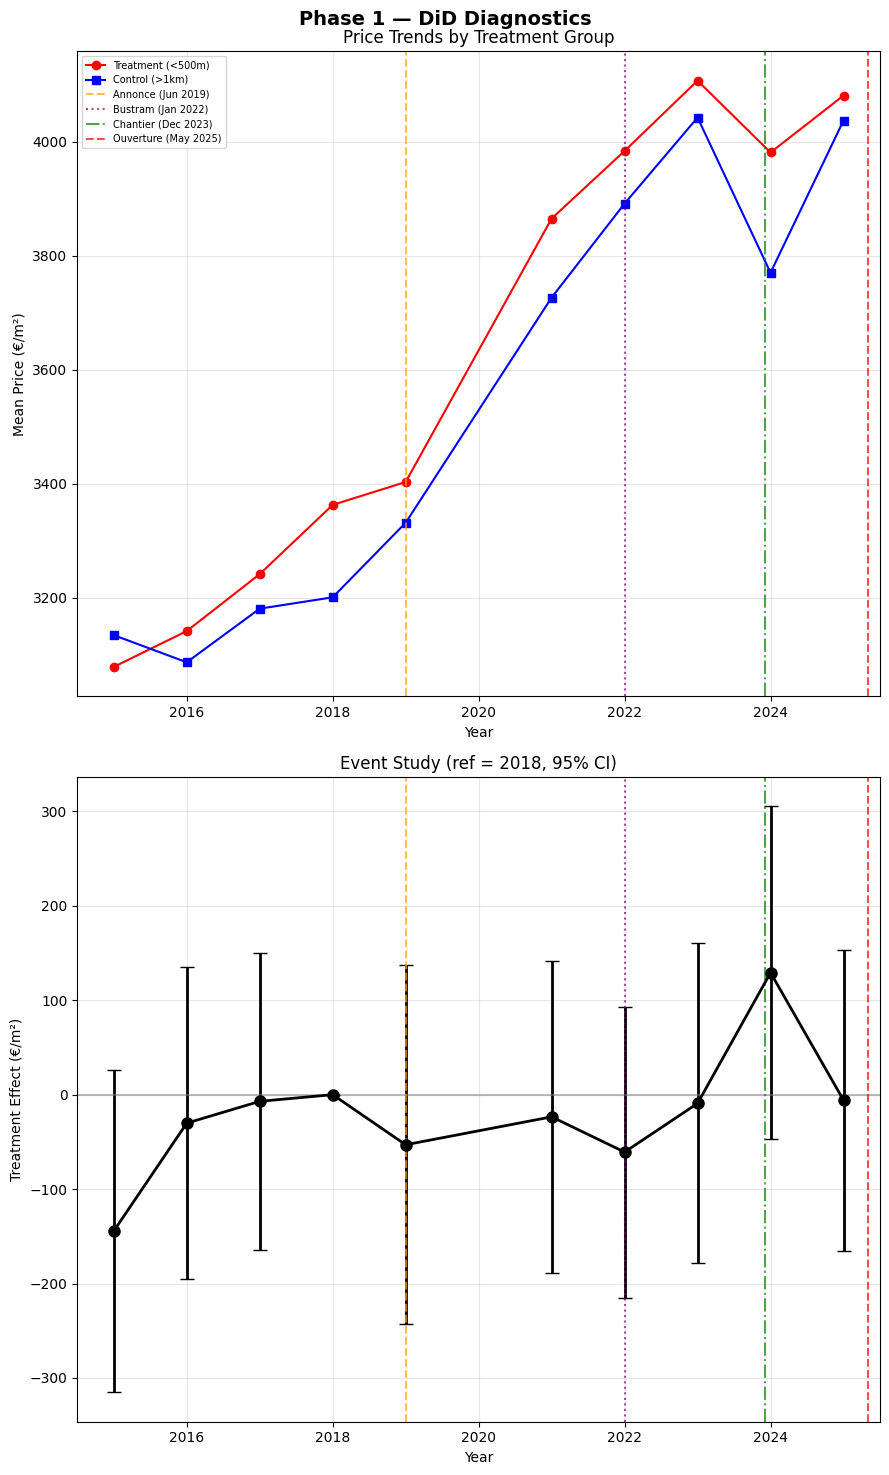

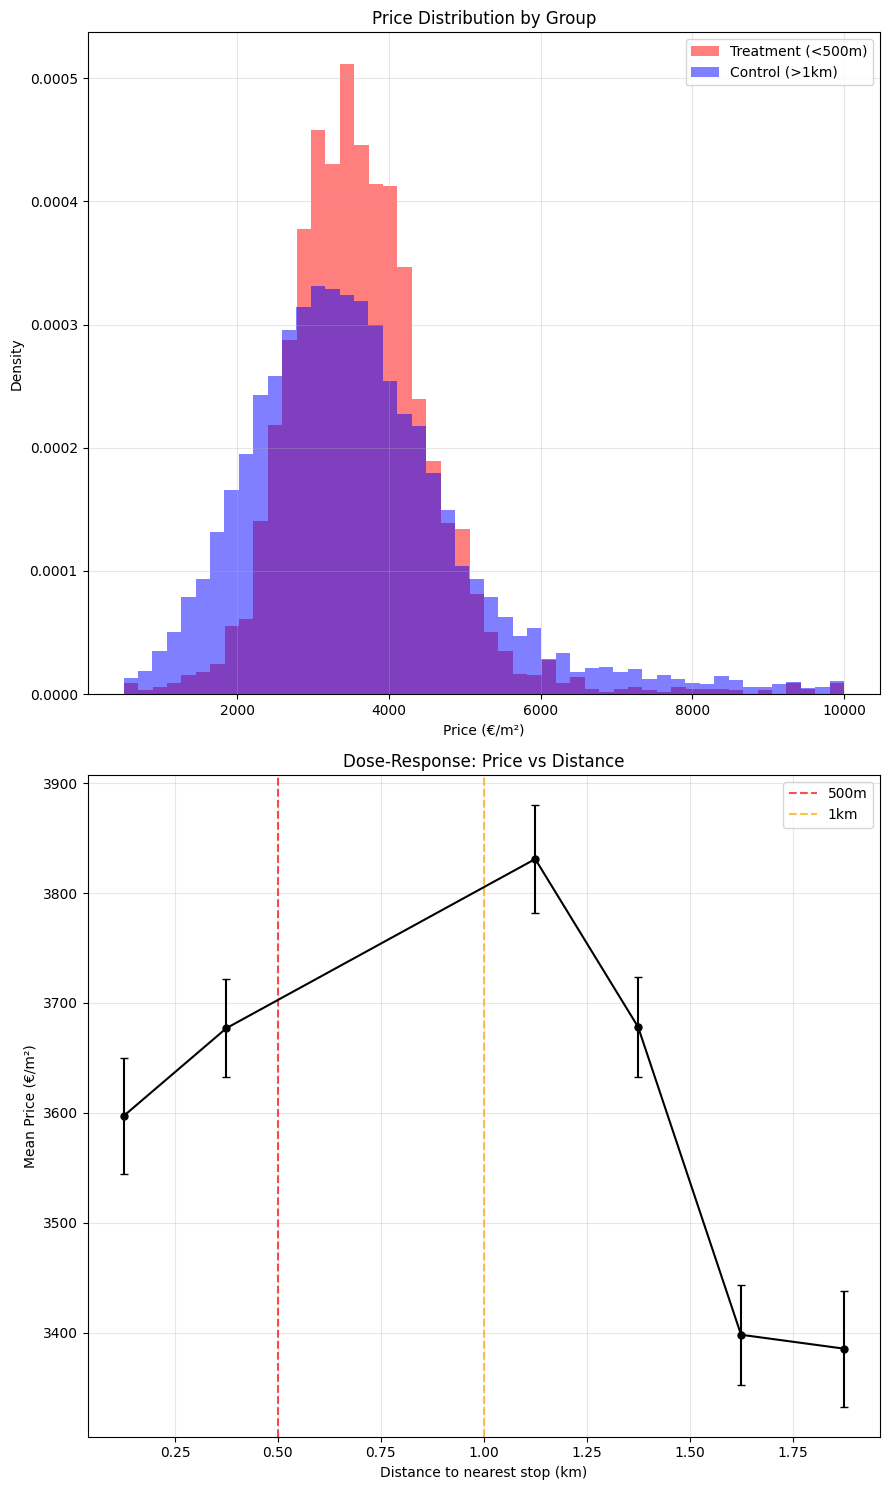

In [ ]:

# PHASE 1 — DiD PART 4: Diagnostic plots

fig, axes = plt.subplots(2, 1, figsize=(9, 15))
fig.suptitle('Phase 1 — DiD Diagnostics', fontsize=14, fontweight='bold')

# 4a. Mean price by group over time (with all 4 shock vlines)
yearly = df_p1_did.groupby(['year', 'treatment'])['price_m2'].mean().unstack()
if 0 in yearly.columns and 1 in yearly.columns:
    axes[0].plot(yearly.index, yearly[1], 'ro-', label='Treatment (<500m)')
    axes[0].plot(yearly.index, yearly[0], 'bs-', label='Control (>1km)')
    for x, c, ls, lbl in [(2019, 'orange', '--', 'Annonce (Jun 2019)'),
                           (2022, 'purple', ':',  'Bustram (Jan 2022)'),
                           (2023.92, 'green',  '-.', 'Chantier (Dec 2023)'),
                           (2025.33, 'red',    '--', 'Ouverture (May 2025)')]:
        axes[0].axvline(x, color=c, ls=ls, alpha=0.7, label=lbl)
axes[0].set(xlabel='Year', ylabel='Mean Price (€/m²)',
               title='Price Trends by Treatment Group')
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

# 4b. Event study plot
axes[1].errorbar(event_p1['year'], event_p1['coef'],
                     yerr=1.96 * event_p1['se'],
                     fmt='ko-', lw=2, ms=8, capsize=5)
axes[1].axhline(0, color='grey', alpha=0.5)
for x, c, ls in [(2019, 'orange', '--'), (2022, 'purple', ':'),
                  (2023.92, 'green', '-.'), (2025.33, 'red', '--')]:
    axes[1].axvline(x, color=c, ls=ls, alpha=0.7)
axes[1].set(xlabel='Year', ylabel='Treatment Effect (€/m²)',
               title=f'Event Study (ref = {REF_YEAR}, 95% CI)')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(9, 15))

# 4c. Price distribution
for grp, lbl, col in [(1, 'Treatment (<500m)', 'red'), (0, 'Control (>1km)', 'blue')]:
    sub = df_p1_did[df_p1_did['treatment'] == grp]['price_m2']
    axes[0].hist(sub, bins=50, alpha=0.5, color=col, label=lbl, density=True)
axes[0].set(xlabel='Price (€/m²)', ylabel='Density',
               title='Price Distribution by Group')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 4d. Dose-response
bins = np.arange(0, 3.5, 0.25)
df_d = df_p1_did.copy()
df_d['db'] = pd.cut(df_d['dist_p1_km'], bins=bins)
dose = df_d.groupby('db', observed=True).agg(
    mean=('price_m2', 'mean'),
    n=('price_m2', 'count'),
    se=('price_m2', lambda x: x.std() / np.sqrt(len(x)) if len(x) > 0 else np.nan)
).dropna()
centers = [iv.mid for iv in dose.index]
axes[1].errorbar(centers, dose['mean'], yerr=1.96 * dose['se'],
                     fmt='ko-', ms=5, capsize=3)
axes[1].axvline(0.5, color='r', ls='--', alpha=0.7, label='500m')
axes[1].axvline(1.0, color='orange', ls='--', alpha=0.7, label='1km')
axes[1].set(xlabel='Distance to nearest stop (km)', ylabel='Mean Price (€/m²)',
               title='Dose-Response: Price vs Distance')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [ ]:

# PHASE 1 — DiD PART 5: Summary table

print("\n" + "=" * 80)
print("SUMMARY — PHASE 1 (in-service line)")
print("=" * 80)
print(f"{'Model':<55} {'Coef':>10} {'SE':>10} {'p-value':>10} {'Sig':>5}")
print("-" * 95)

results = [
    ("P1-M1: Proximity premium",                        m_p1_1, 'treatment'),
    ("P1-M2: Announcement DiD (no controls)",           m_p1_2, 'did_announcement'),
    ("P1-M3: Announcement DiD (ctrl+FE+Line5)",         m_p1_3, 'did_announcement'),
    ("P1-M3b: Announcement DiD (log, x100=%)",          m_p1_3b, 'did_announcement'),
    ("P1-M4: Restart DiD (Jan 2022+, ctrl+FE)",         m_p1_4, 'did_restart'),
    ("P1-M5: Construction DiD (Dec 2023+, ctrl+FE)",    m_p1_5, 'did_construction'),
    ("P1-M6: Opening DiD (May 2025+, ctrl+FE)",         m_p1_6, 'did_opening'),
    ("P1-M3-cl: Announcement DiD (clustered SE)",       m_p1_3_cl, 'did_announcement'),
]

for name, mdl, var in results:
    if mdl is None:
        print(f"{name:<55} {'—':>10} {'—':>10} {'skipped':>10} {'':>5}")
        continue
    coef = mdl.params[var] * (100 if 'log' in name else 1)
    se   = mdl.bse[var]   * (100 if 'log' in name else 1)
    p    = mdl.pvalues[var]
    sig  = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    print(f"{name:<55} {coef:>10.2f} {se:>10.2f} {p:>10.4f} {sig:>5}")

print("-" * 95)
print(f"\nEvent study (ref = {REF_YEAR}):")
for _, r in event_p1.iterrows():
    yr = int(r['year'])
    sig = '***' if r['pval'] < 0.01 else ('**' if r['pval'] < 0.05 else ('*' if r['pval'] < 0.1 else ''))
    pv = f"{r['pval']:.4f}" if not np.isnan(r['pval']) else "ref"
    flag = '(ref)' if yr == REF_YEAR else '      '
    print(f"  {yr}{flag}  {r['coef']:>10.2f}  {r['se']:>8.2f}  {pv:>8}  {sig}")

print("\n" + "=" * 80)
print("INTERPRETATION:")
print("- 4 distinct shocks tested (announcement / restart / construction / opening)")
print("- Treatment: <500m from existing stops | Control: >1km | Buffer 0.5-1km excluded")
print("- Headline SE: HC1 robust. Clustered SE in M3-cl (5 PCs is too few for inference).")
print(f"- Postal codes (Phase 1): {P1_POSTAL_CODES}")
print("- Line 5 distance controlled for in M3-M6 (corridor overlaps with Line 5).")
print("=" * 80)



SUMMARY — PHASE 1 (in-service line)
Model                                                         Coef         SE    p-value   Sig
-----------------------------------------------------------------------------------------------
P1-M1: Proximity premium                                     87.71      20.07     0.0000   ***
P1-M2: Announcement DiD (no controls)                        53.15      40.06     0.1846      
P1-M3: Announcement DiD (ctrl+FE+Line5)                      48.22      37.69     0.2008      
P1-M3b: Announcement DiD (log, x100=%)                       -0.63       1.06     0.5489      
P1-M4: Restart DiD (Jan 2022+, ctrl+FE)                      54.85      38.16     0.1506      
P1-M5: Construction DiD (Dec 2023+, ctrl+FE)                100.78      46.60     0.0306    **
P1-M6: Opening DiD (May 2025+, ctrl+FE)                      58.09      68.36     0.3954      
P1-M3-cl: Announcement DiD (clustered SE)                    48.22      95.26     0.6128      
------------

In [ ]:

# PHASE 1 — ROBUSTNESS BATTERY

# (a) Drop 2015 from the pre-period and re-test parallel trends.
#     The single 2015 coefficient (-€172**) drove the V8 F-test rejection.
# (b) Grid-cell FE & cluster (50m → 500m grid).
# (c) Conley spatial HAC SE.
# (d) Apartments vs houses split.


# (a) Drop 2015 → re-estimate event study & parallel-trends F-test

section("PHASE 1 — Robustness: drop 2015 and re-test parallel trends")

df_p1_did_no15 = df_p1_did[df_p1_did['year'] != 2015].copy()
print(f"Sample without 2015: {len(df_p1_did_no15):,}  "
      f"(was {len(df_p1_did):,})")

# Rebuild dummies on the restricted sample (postal codes / quarter)
postal_dum_no15 = pd.get_dummies(df_p1_did_no15['code_postal'], prefix='cp', drop_first=True, dtype=int)
quarter_dum_no15 = pd.get_dummies(df_p1_did_no15['quarter'],    prefix='Q',  drop_first=True, dtype=int)

# Year dummies + interactions, ref = 2018
REF_YEAR_no15 = 2018
year_dum_no15 = pd.get_dummies(df_p1_did_no15['year'], prefix='yr', dtype=int)
yr_cols_no15 = [c for c in year_dum_no15.columns if c != f'yr_{REF_YEAR_no15}']
year_dum_no15 = year_dum_no15[yr_cols_no15]
inter_no15 = pd.concat(
    {f'treat_x_{c}': df_p1_did_no15['treatment'] * year_dum_no15[c] for c in yr_cols_no15},
    axis=1
)
X_es_no15 = sm.add_constant(pd.concat([
    df_p1_did_no15[['treatment', 'is_apartment', 'log_surface'] + LINE5_CONTROLS],
    year_dum_no15, inter_no15, postal_dum_no15, quarter_dum_no15
], axis=1))

m_p1_es_no15 = run_ols(df_p1_did_no15['price_m2'], X_es_no15, cov='HC1',
                        model_name=f"P1 ES (drop 2015, ref={REF_YEAR_no15}, HC1)")

# Parallel trends F-test on the remaining pre-years (2016, 2017)
years_in_no15 = sorted(df_p1_did_no15['year'].unique())
pre_cols_no15 = [f'treat_x_yr_{y}' for y in years_in_no15
                 if y < 2019 and y != REF_YEAR_no15
                 and f'treat_x_yr_{y}' in m_p1_es_no15.params.index]
print(f"Pre-period interactions tested: {pre_cols_no15}")

if len(pre_cols_no15) >= 1:
    R = np.zeros((len(pre_cols_no15), len(m_p1_es_no15.params)))
    for i, c in enumerate(pre_cols_no15):
        R[i, m_p1_es_no15.params.index.get_loc(c)] = 1
    ft = m_p1_es_no15.f_test(R)
    fval = float(np.squeeze(ft.fvalue))
    pval = float(np.squeeze(ft.pvalue))
    print(f"\nParallel trends F-test (drop 2015):  F = {fval:.3f},  p = {pval:.4f}")
    print("   Still rejected at 5%" if pval < 0.05
          else "   Cannot reject parallel trends after dropping 2015")
else:
    print("\n No pre-period interactions left after dropping 2015")

# Print coefficients
print("\nEvent-study coefficients (drop 2015):")
for yr in years_in_no15:
    if yr == REF_YEAR_no15:
        print(f"  {yr} (ref)")
        continue
    p = f'treat_x_yr_{yr}'
    if p in m_p1_es_no15.params.index:
        c, s, pv = m_p1_es_no15.params[p], m_p1_es_no15.bse[p], m_p1_es_no15.pvalues[p]
        sig = '***' if pv < 0.01 else '**' if pv < 0.05 else '*' if pv < 0.1 else ''
        print(f"  {yr}        {c:>10.2f}  {s:>8.2f}  p={pv:.4f}  {sig}")

# ──────────────────────────────────────────────────────────────
# (b) Phase 1 — grid FE / cluster
# ──────────────────────────────────────────────────────────────
section("PHASE 1 — M3-grid: FE & cluster at 500m grid cell level")

if 'grid_id' not in df_p1_did.columns:
    df_p1_did = add_grid_id(df_p1_did, grid_km=0.5)

n_grid_p1 = df_p1_did['grid_id'].nunique()
print(f"Phase 1 grid cells: {n_grid_p1:,}")
grid_dum_p1 = pd.get_dummies(df_p1_did['grid_id'], prefix='g', drop_first=True, dtype=int)

X3_p1_grid = sm.add_constant(pd.concat([
    df_p1_did[['treatment', 'post_announcement', 'did_announcement',
               'year', 'is_apartment', 'log_surface'] + LINE5_CONTROLS],
    grid_dum_p1, quarter_dummies_p1
], axis=1))

m_p1_3_grid = run_ols(df_p1_did['price_m2'], X3_p1_grid,
                       cov='cluster', groups=df_p1_did['grid_id'],
                       model_name=f"P1-M3-grid: FE+cluster on {n_grid_p1} grid cells")
print_did_result(m_p1_3_grid, 'did_announcement',
                 "Announcement effect (grid FE & cluster)")

# Log spec
section("PHASE 1 — M3-grid-log")
m_p1_3_grid_log = run_ols(df_p1_did['log_price_m2'], X3_p1_grid,
                           cov='cluster', groups=df_p1_did['grid_id'],
                           model_name="P1-M3-grid-log")
c, p = m_p1_3_grid_log.params['did_announcement'], m_p1_3_grid_log.pvalues['did_announcement']
print(f"\n→ Announcement effect (log, grid FE+cluster): "
      f"{c:.4f} ≈ {c*100:.2f}% (p={p:.4f})")


# (c) Phase 1 — Conley spatial HAC SE

section("PHASE 1 — M3-conley: Conley spatial HAC SE")

print("Conley SE on M3 (postal FE, level):")
report_conley(m_p1_3, df_p1_did, 'did_announcement',
              cutoff_km=0.5, label="P1-M3-conley")
report_conley(m_p1_3, df_p1_did, 'did_announcement',
              cutoff_km=1.0, label="P1-M3-conley")

print("\nConley SE on M3-grid (grid FE):")
report_conley(m_p1_3_grid, df_p1_did, 'did_announcement',
              cutoff_km=0.5, label="P1-M3-grid-conley")


# (d) Phase 1 — Apartments vs Houses

type_results_p1 = {}
for ptype, label_short in [('Appartement', 'Apt'), ('Maison', 'House')]:
    section(f"PHASE 1 — M3 split: {ptype}s only")
    sub = df_p1_did[df_p1_did['type_local'] == ptype].copy()
    n_t = (sub['treatment'] == 1).sum()
    n_c = (sub['treatment'] == 0).sum()
    print(f"  Sample: {len(sub):,}  (treated={n_t:,}, control={n_c:,})")
    if n_t < 50 or n_c < 50:
        print(f"   Skipped: too few obs in one group")
        continue

    sub_postal  = pd.get_dummies(sub['code_postal'], prefix='cp', drop_first=True, dtype=int)
    sub_quarter = pd.get_dummies(sub['quarter'],     prefix='Q',  drop_first=True, dtype=int)
    X_sub = sm.add_constant(pd.concat([
        sub[['treatment', 'post_announcement', 'did_announcement',
             'year', 'log_surface'] + LINE5_CONTROLS],
        sub_postal, sub_quarter
    ], axis=1))

    m_lvl = run_ols(sub['price_m2'], X_sub, cov='HC1',
                     model_name=f"P1-M3 — {ptype}s, level")
    print_did_result(m_lvl, 'did_announcement',
                     f"Announcement effect ({ptype}s, level)")

    m_log = run_ols(np.log(sub['price_m2']), X_sub, cov='HC1',
                     model_name=f"P1-M3 — {ptype}s, log")
    c_log = m_log.params['did_announcement']
    p_log = m_log.pvalues['did_announcement']
    s = "***" if p_log < 0.01 else "**" if p_log < 0.05 else "*" if p_log < 0.1 else "n.s."
    print(f"\n→ Announcement effect ({ptype}s, log): "
          f"{c_log:.4f} ≈ {c_log*100:.2f}%  (p={p_log:.4f}) {s}")

    type_results_p1[ptype] = (m_lvl, m_log, sub)

print("\n" + "=" * 80)
print("PHASE 1 — TYPE HETEROGENEITY SUMMARY")
print("=" * 80)
print(f"{'Sample':<22} {'N':>8} {'Coef (€/m²)':>13} {'SE':>9} {'p':>9}  "
      f"{'Coef (%)':>10} {'p (log)':>9}")
print("-" * 92)
for ptype, (m_lvl, m_log, sub) in type_results_p1.items():
    print(f"{ptype:<22} {len(sub):>8,} "
          f"{m_lvl.params['did_announcement']:>13.2f} "
          f"{m_lvl.bse['did_announcement']:>9.2f} "
          f"{m_lvl.pvalues['did_announcement']:>9.4f}  "
          f"{m_log.params['did_announcement']*100:>10.2f} "
          f"{m_log.pvalues['did_announcement']:>9.4f}")
print("-" * 92)
print(f"Pooled P1-M3 for reference:  €{m_p1_3.params['did_announcement']:.2f}/m²  "
      f"({m_p1_3b.params['did_announcement']*100:.2f}%)")
print("=" * 80)



############################################################
PHASE 1 — Robustness: drop 2015 and re-test parallel trends
############################################################
Sample without 2015: 15,877  (was 17,390)

P1 ES (drop 2015, ref=2018, HC1)
                       Coef.    Std.Err.          z          P>|z|       [0.025       0.975]
const            6866.765819  120.425796  57.020722   0.000000e+00  6630.735596  7102.796043
treatment          64.982853   64.708402   1.004241   3.152623e-01   -61.843284   191.808989
is_apartment    -1351.448227   43.279981 -31.225712  4.771183e-214 -1436.275430 -1266.621024
log_surface      -630.879736   20.806841 -30.320785  6.101197e-202  -671.660395  -590.099078
dist_line5_km      83.456946   20.093241   4.153483   3.274519e-05    44.074916   122.838976
near_line5_500m   224.900989   32.090004   7.008444   2.409832e-12   162.005738   287.796240
yr_2016          -178.552824   48.152797  -3.708047   2.088640e-04  -272.930571   -84.1750

/opt/anaconda3/envs/tf-metal/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 105, but rank is 10
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/envs/tf-metal/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 105, but rank is 10
  warnings.warn('covariance of constraints does not have full '


  Conley: N=17,390, pairs<0.5km = 13,952,813 (avg 1605 neighbors per obs)

→ P1-M3-conley (cutoff = 0.5 km): €48.22/m²  (SE=71.03, p=0.4972) n.s.
  Conley: N=17,390, pairs<1.0km = 35,522,186 (avg 4085 neighbors per obs)

→ P1-M3-conley (cutoff = 1.0 km): €48.22/m²  (SE=70.27, p=0.4926) n.s.

Conley SE on M3-grid (grid FE):
  Conley: N=17,390, pairs<0.5km = 13,952,813 (avg 1605 neighbors per obs)

→ P1-M3-grid-conley (cutoff = 0.5 km): €13.05/m²  (SE=144.73, p=0.9282) n.s.

############################################################
PHASE 1 — M3 split: Appartements only
############################################################
  Sample: 15,723  (treated=3,209, control=12,514)

P1-M3 — Appartements, level
                          Coef.      Std.Err.          z          P>|z|         [0.025        0.975]
const             -97666.838491  13621.713068  -7.169938   7.503173e-13 -124364.905512 -70968.771470
treatment            -55.087109     34.897838  -1.578525   1.144451e-01    -123.4

In [ ]:

# PHASE 2 — EXTENSION DiD

df_p2_did = df_p2.copy()

df_p2_did['treatment'] = np.where(
    df_p2_did['dist_p2_km'] < 0.5, 1,
    np.where(df_p2_did['dist_p2_km'] > 1.0, 0, np.nan)
)
df_p2_did = df_p2_did.dropna(subset=['treatment']).copy()
df_p2_did['treatment'] = df_p2_did['treatment'].astype(int)

df_p2_did['post_announcement'] = (
    (df_p2_did['year'] > 2019) |
    ((df_p2_did['year'] == 2019) & (df_p2_did['month'] >= 6))
).astype(int)
df_p2_did['post_works_prep'] = (
    (df_p2_did['year'] > 2025) |
    ((df_p2_did['year'] == 2025) & (df_p2_did['month'] >= 11))
).astype(int)

df_p2_did['did_announcement'] = df_p2_did['treatment'] * df_p2_did['post_announcement']
df_p2_did['did_works_prep']   = df_p2_did['treatment'] * df_p2_did['post_works_prep']

df_p2_did['log_price_m2'] = np.log(df_p2_did['price_m2'])
df_p2_did['is_apartment'] = (df_p2_did['type_local'] == 'Appartement').astype(int)
df_p2_did['log_surface']  = np.log(df_p2_did['surface_reelle_bati'])
df_p2_did['quarter']      = ((df_p2_did['month'] - 1) // 3 + 1)

if 'dist_line5_km' not in df_p2_did.columns:
    df_p2_did['dist_line5_km']    = calc_dist_to_stops(df_p2_did, line5_array)
    df_p2_did['near_line5_500m']  = (df_p2_did['dist_line5_km'] < 0.5).astype(int)

# Phase 2 corridor is mostly outside Line 5's reach (Le Crès / Vendargues
# / Castries are east/north of Montpellier); near_line5_500m may be
# constant 0 in this sample → perfectly collinear with the constant.
# Drop it from the controls if it has < 50 ones or zero variance.
n_near_line5 = int(df_p2_did['near_line5_500m'].sum())
LINE5_CTRLS_P2_BASE = ['dist_line5_km', 'near_line5_500m']
if n_near_line5 < 50 or df_p2_did['near_line5_500m'].nunique() < 2:
    print(f" Phase 2: near_line5_500m has {n_near_line5} ones — "
          f"dropping it (collinear with constant in this sample).")
    LINE5_CTRLS_P2_BASE = ['dist_line5_km']

n_t = df_p2_did['treatment'].sum()
n_c = (df_p2_did['treatment'] == 0).sum()
n_post_ann = df_p2_did['post_announcement'].sum()
n_post_wp  = df_p2_did['post_works_prep'].sum()

print("=" * 60)
print("PHASE 2 — EXTENSION SAMPLE DESCRIPTION")
print("=" * 60)
print(f"DiD sample (excl. buffer): {len(df_p2_did):,}")
print(f"  Treatment (<500m): {n_t:,}  | Control (>1km): {n_c:,}")
print(f"  Post-announcement (Jun 2019+): {n_post_ann:,}")
print(f"  Post-works-prep   (Nov 2025+): {n_post_wp:,}")
print(f"\nYearly counts:")
print(df_p2_did['year'].value_counts().sort_index())

if n_t < 50 or n_c < 50:
    print(f"\n INSUFFICIENT SAMPLE: T={n_t}, C={n_c}. Phase 2 regressions skipped.")
else:
    postal_dummies_p2  = pd.get_dummies(df_p2_did['code_postal'], prefix='cp', drop_first=True, dtype=int)
    quarter_dummies_p2 = pd.get_dummies(df_p2_did['quarter'],     prefix='Q',  drop_first=True, dtype=int)
    LINE5_CTRLS_P2 = LINE5_CTRLS_P2_BASE
    HEADLINE_COV_P2 = 'HC1'

    section("PHASE 2 — MODEL 1: PROXIMITY PREMIUM")
    X = sm.add_constant(df_p2_did[['treatment', 'year']])
    m_p2_1 = run_ols(df_p2_did['price_m2'], X, cov=HEADLINE_COV_P2,
                     model_name="P2-M1: Proximity Premium")
    print_did_result(m_p2_1, 'treatment', "Proximity premium (Phase 2)")

    if n_post_ann >= 30:
        section("PHASE 2 — MODEL 2: ANNOUNCEMENT DiD (ctrl + FE + Line 5)")
        core = df_p2_did[['treatment', 'post_announcement', 'did_announcement',
                          'year', 'is_apartment', 'log_surface'] + LINE5_CTRLS_P2]
        X2 = sm.add_constant(pd.concat([core, postal_dummies_p2, quarter_dummies_p2], axis=1))
        m_p2_2 = run_ols(df_p2_did['price_m2'], X2, cov=HEADLINE_COV_P2,
                         model_name="P2-M2: DiD Announcement (Jun 2019+)")
        print_did_result(m_p2_2, 'did_announcement', "Announcement effect (Phase 2)")

        section("PHASE 2 — MODEL 2b: ANNOUNCEMENT DiD (LOG)")
        m_p2_2b = run_ols(df_p2_did['log_price_m2'], X2, cov=HEADLINE_COV_P2,
                          model_name="P2-M2b: log(price/m²)")
        c, p = m_p2_2b.params['did_announcement'], m_p2_2b.pvalues['did_announcement']
        s = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else "n.s."
        print(f"\n→ P2 Announcement (log): {c:.4f} ≈ {c*100:.2f}%  (p={p:.4f}) {s}")
    else:
        print(f"\n P2-M2 skipped: only {n_post_ann} post-announcement obs.")
        m_p2_2 = m_p2_2b = None

    if n_post_wp >= 30:
        section("PHASE 2 — MODEL 3: WORKS-PREP DiD (Nov 2025+)")
        core = df_p2_did[['treatment', 'post_works_prep', 'did_works_prep',
                          'year', 'is_apartment', 'log_surface'] + LINE5_CTRLS_P2]
        X3 = sm.add_constant(pd.concat([core, postal_dummies_p2, quarter_dummies_p2], axis=1))
        m_p2_3 = run_ols(df_p2_did['price_m2'], X3, cov=HEADLINE_COV_P2,
                         model_name="P2-M3: DiD Works-Prep (Nov 2025+)")
        print_did_result(m_p2_3, 'did_works_prep', "Works-prep effect (Phase 2)")
    else:
        print(f"\n P2-M3 skipped: only {n_post_wp} post-works-prep obs.")
        m_p2_3 = None

    print("\n" + "=" * 80)
    print("SUMMARY — PHASE 2 (extension)")
    print("=" * 80)
    print(f"{'Model':<55} {'Coef':>10} {'SE':>10} {'p-value':>10} {'Sig':>5}")
    print("-" * 95)
    for name, mdl, var, scale in [
        ("P2-M1: Proximity premium",                m_p2_1,  'treatment',        1),
        ("P2-M2: Announcement DiD (Jun 2019+)",     m_p2_2,  'did_announcement', 1),
        ("P2-M2b: Announcement DiD (log, %)",       m_p2_2b, 'did_announcement', 100),
        ("P2-M3: Works-prep DiD (Nov 2025+) [PLACEBO]", m_p2_3,  'did_works_prep',   1),
    ]:
        if mdl is None:
            print(f"{name:<55} {'—':>10} {'—':>10} {'skipped':>10} {'':>5}")
            continue
        coef = mdl.params[var] * scale
        se   = mdl.bse[var]   * scale
        p    = mdl.pvalues[var]
        sig  = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
        print(f"{name:<55} {coef:>10.2f} {se:>10.2f} {p:>10.4f} {sig:>5}")
    print("-" * 95)
    print("\n P2-M3 is a PLACEBO, not an estimated effect.")
    print("  Works-prep started 3 Nov 2025; the DVF data ends Dec 2025,")
    print("  so the post-period contains at most ~2 months of transactions.")
    print("  The point estimate is uninformative and should not be cited.")
    print(f"\nPostal codes (Phase 2): {P2_POSTAL_CODES}")
    print(f"Communes from JSON: {p2_communes}")
    print("=" * 80)

⚠ Phase 2: near_line5_500m has 0 ones — dropping it (collinear with constant in this sample).
PHASE 2 — EXTENSION SAMPLE DESCRIPTION
DiD sample (excl. buffer): 7,873
  Treatment (<500m): 1,309  | Control (>1km): 6,564
  Post-announcement (Jun 2019+): 4,648
  Post-works-prep   (Nov 2025+): 146

Yearly counts:
year
2015     598
2016     641
2017     820
2018     835
2019     616
2021     993
2022    1016
2023     851
2024     686
2025     817
Name: count, dtype: int64

############################################################
PHASE 2 — MODEL 1: PROXIMITY PREMIUM
############################################################

P2-M1: Proximity Premium
                   Coef.     Std.Err.          z          P>|z|         [0.025         0.975]
const     -252130.728297  8873.740148 -28.413130  1.391968e-177 -269522.939395 -234738.517199
treatment      51.534816    37.512487   1.373804   1.695024e-01     -21.988307     125.057938
year          126.592768     4.392738  28.818647  1.252659e-1

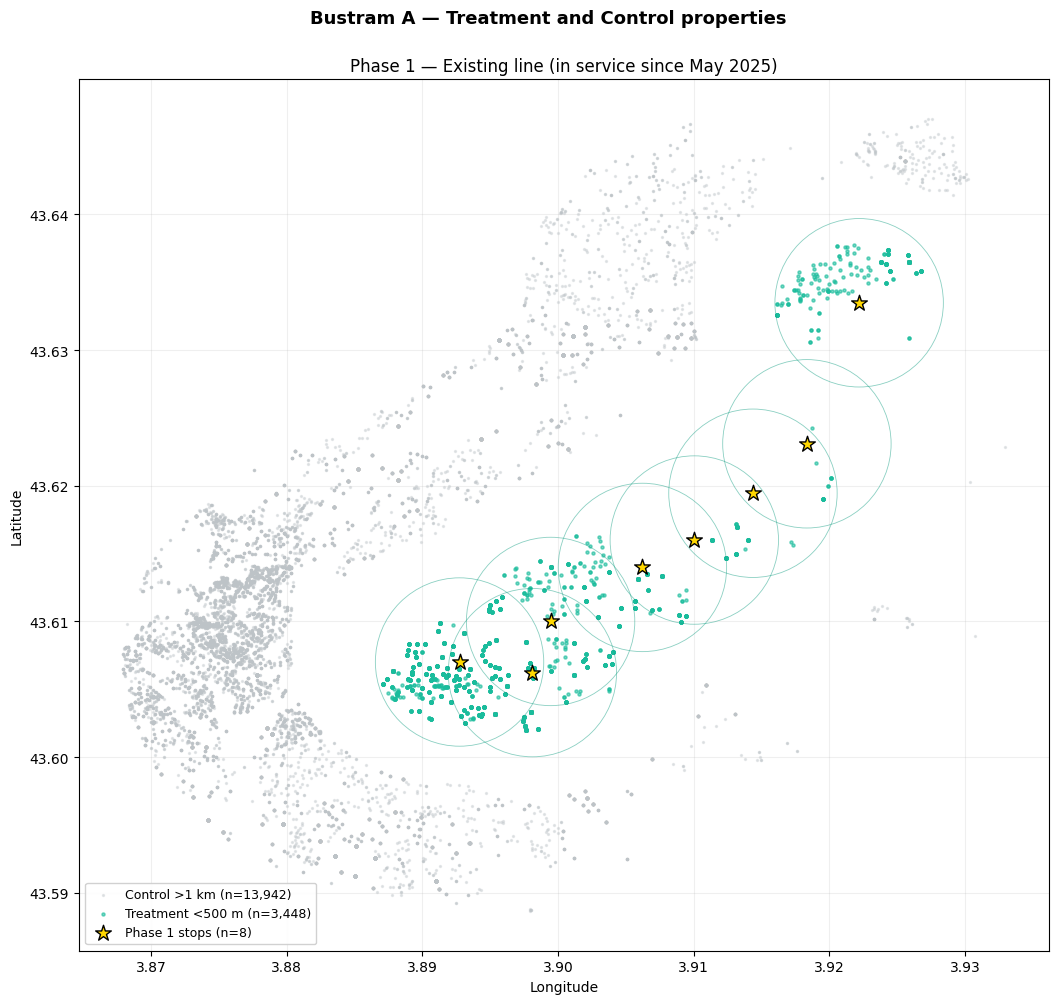

In [ ]:

# MAP — Bustram A: Treatment vs Control (Phase 1 + Phase 2)

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 10))

# ---------- Phase 1 (existing line) ----------
ctrl_p1  = df_p1_did[df_p1_did['treatment'] == 0]
treat_p1 = df_p1_did[df_p1_did['treatment'] == 1]

ax.scatter(ctrl_p1['longitude'], ctrl_p1['latitude'],
           c='#bdc3c7', s=2, alpha=0.35,
           label=f'Control >1 km (n={len(ctrl_p1):,})', zorder=2)
ax.scatter(treat_p1['longitude'], treat_p1['latitude'],
           c='#1abc9c', s=5, alpha=0.6,
           label=f'Treatment <500 m (n={len(treat_p1):,})', zorder=4)

# Phase 1 stops
ax.scatter(p1_stops[:, 1], p1_stops[:, 0],
           c='gold', s=140, marker='*',
           edgecolors='black', linewidths=1.0,
           label=f'Phase 1 stops (n={len(p1_stops)})', zorder=6)
for lat, lon in p1_stops:
    r = 0.5 / (111.32 * np.cos(np.radians(lat)))
    ax.add_patch(plt.Circle((lon, lat), r, fill=False,
                            color='#16a085', linewidth=0.6, alpha=0.5, zorder=5))

ax.set(xlabel='Longitude', ylabel='Latitude',
       title='Phase 1 — Existing line (in service since May 2025)')
ax.legend(fontsize=9, loc='lower left', framealpha=0.9)
ax.set_aspect('equal'); ax.grid(alpha=0.2)

fig.suptitle('Bustram A — Treatment and Control properties',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

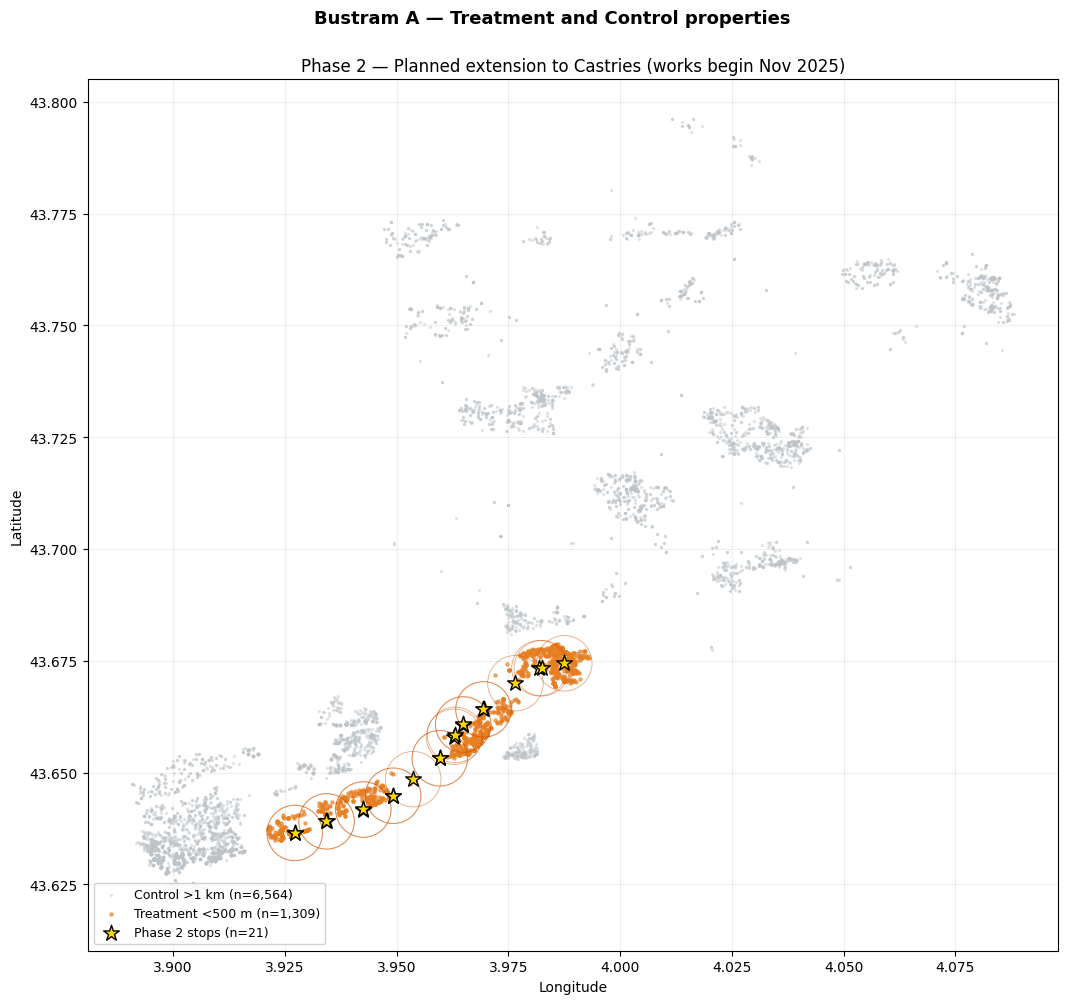

In [ ]:

# MAP — Bustram A: Treatment vs Control (Phase 1 + Phase 2)

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 10))

# ---------- Phase 2 (planned extension) ----------
ctrl_p2  = df_p2_did[df_p2_did['treatment'] == 0]
treat_p2 = df_p2_did[df_p2_did['treatment'] == 1]

ax.scatter(ctrl_p2['longitude'], ctrl_p2['latitude'],
           c='#bdc3c7', s=2, alpha=0.35,
           label=f'Control >1 km (n={len(ctrl_p2):,})', zorder=2)
ax.scatter(treat_p2['longitude'], treat_p2['latitude'],
           c='#e67e22', s=5, alpha=0.6,
           label=f'Treatment <500 m (n={len(treat_p2):,})', zorder=4)

# Phase 2 stops
ax.scatter(p2_stops[:, 1], p2_stops[:, 0],
           c='gold', s=140, marker='*',
           edgecolors='black', linewidths=1.0,
           label=f'Phase 2 stops (n={len(p2_stops)})', zorder=6)
for lat, lon in p2_stops:
    r = 0.5 / (111.32 * np.cos(np.radians(lat)))
    ax.add_patch(plt.Circle((lon, lat), r, fill=False,
                            color='#d35400', linewidth=0.6, alpha=0.5, zorder=5))

ax.set(xlabel='Longitude', ylabel='Latitude',
       title='Phase 2 — Planned extension to Castries (works begin Nov 2025)')
ax.legend(fontsize=9, loc='lower left', framealpha=0.9)
ax.set_aspect('equal'); ax.grid(alpha=0.2)

fig.suptitle('Bustram A — Treatment and Control properties',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

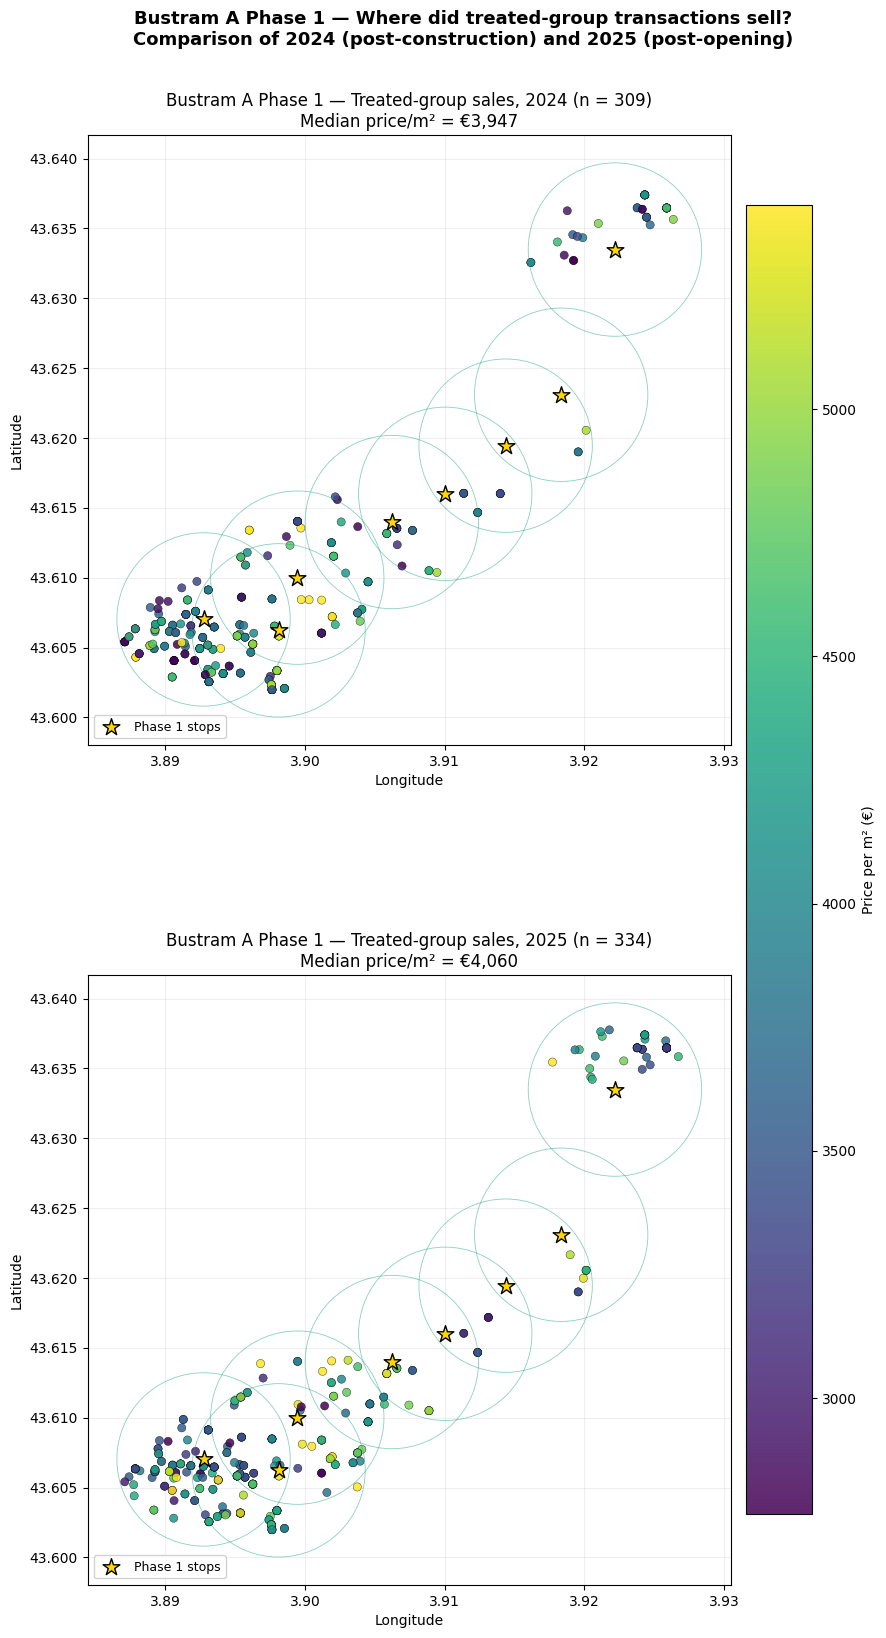


Treated-group transactions, by year:
  2024: n=309, mean €3,982/m², median €3,947/m², min €1,127, max €9,247
  2025: n=334, mean €4,082/m², median €4,060/m², min €1,735, max €9,375


In [ ]:

# MAPS — Bustram A Phase 1: treated-group sale prices
# Side-by-side comparison of 2024 and 2025

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Pull treated-group transactions for 2024 and 2025
treat_p1 = df_p1_did[df_p1_did['treatment'] == 1]
sales_2024 = treat_p1[treat_p1['year'] == 2024]
sales_2025 = treat_p1[treat_p1['year'] == 2025]

# Use a shared colour scale across both years so prices are visually comparable.
# Trim the colour scale to 5th–95th percentile of the pooled data to keep
# extreme outliers from washing out the gradient.
pooled = treat_p1[treat_p1['year'].isin([2024, 2025])]['price_m2']
vmin, vmax = np.percentile(pooled, [5, 95])

fig, axes = plt.subplots(2, 1, figsize=(10, 20))

for ax, df_yr, year_label in zip(
    axes,
    [sales_2024, sales_2025],
    [f'2024 (n = {len(sales_2024):,})',
     f'2025 (n = {len(sales_2025):,})']
):
    # Phase 1 stops as gold stars
    ax.scatter(p1_stops[:, 1], p1_stops[:, 0],
               c='gold', s=160, marker='*',
               edgecolors='black', linewidths=1.0, zorder=6,
               label=f'Phase 1 stops')

    # 500 m buffer rings (visual reference for the treatment radius)
    for lat, lon in p1_stops:
        r = 0.5 / (111.32 * np.cos(np.radians(lat)))
        ax.add_patch(plt.Circle((lon, lat), r, fill=False,
                                color='#16a085', linewidth=0.6,
                                alpha=0.5, zorder=5))

    # Treated transactions, coloured by price/m²
    sc = ax.scatter(df_yr['longitude'], df_yr['latitude'],
                    c=df_yr['price_m2'], cmap='viridis',
                    vmin=vmin, vmax=vmax,
                    s=35, alpha=0.85, edgecolors='black',
                    linewidths=0.3, zorder=4)

    median_price = df_yr['price_m2'].median()
    ax.set(xlabel='Longitude', ylabel='Latitude',
           title=f'Bustram A Phase 1 — Treated-group sales, {year_label}\n'
                 f'Median price/m² = €{median_price:,.0f}')
    ax.legend(fontsize=9, loc='lower left', framealpha=0.9)
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)

# Shared colourbar on the right
cbar = fig.colorbar(sc, ax=axes, shrink=0.85, pad=0.02,
                    label='Price per m² (€)')

fig.suptitle('Bustram A Phase 1 — Where did treated-group transactions sell?\n'
             'Comparison of 2024 (post-construction) and 2025 (post-opening)',
             fontsize=13, fontweight='bold', y=0.92)
plt.show()

# Quick summary table for the prose
print("\nTreated-group transactions, by year:")
for yr in [2024, 2025]:
    sub = treat_p1[treat_p1['year'] == yr]
    print(f"  {yr}: n={len(sub):,}, "
          f"mean €{sub['price_m2'].mean():,.0f}/m², "
          f"median €{sub['price_m2'].median():,.0f}/m², "
          f"min €{sub['price_m2'].min():,.0f}, "
          f"max €{sub['price_m2'].max():,.0f}")

In [ ]:

# DID PART 6: HETEROGENEOUS TREATMENT EFFECTS


for col in ['pre_median_price', 'low_price_area',
            'treat_x_low', 'post_x_low', 'did_x_low']:
    if col in df_did_clean.columns:
        df_did_clean = df_did_clean.drop(columns=[col])

# Resolve which DiD variable is in play
DID_VAR  = 'did_construction_start'  if 'did_construction_start'  in df_did_clean.columns else 'did_announcement'
POST_VAR = 'post_construction_start' if 'post_construction_start' in df_did_clean.columns else 'post_announcement'

# Pre-period mask
pre_mask = df_did_clean[POST_VAR] == 0

pre_median = (
    df_did_clean[pre_mask]
    .groupby('code_postal')['price_m2']
    .median()
)

print("Pre-construction median price/m² by postal code:")
print(pre_median.sort_values().round(0))
median_cutoff = pre_median.median()
print(f"\nOverall median of postal medians: €{median_cutoff:,.0f}/m²")

# NOTE (future work): this dichotomization splits 5 postal codes at the
# median (effectively 2 vs 3 PCs). With grid_id now available, a
# continuous gradient — terciles or quartiles of pre-period median price
# computed at the grid-cell level — would give finer heterogeneity at a
# scale closer to the treatment definition. Out of scope for the current
# revision; flagged in the thesis future-work section.
low_price_map = (pre_median < median_cutoff).astype(int).rename('low_price_area')
df_did_clean = df_did_clean.merge(low_price_map, on='code_postal', how='left')
df_did_clean['low_price_area'] = df_did_clean['low_price_area'].fillna(0).astype(int)

print(f"\nLow-price postal codes (median < €{median_cutoff:,.0f}):")
print(pre_median[pre_median < median_cutoff].round(0))
print(f"\nHigh-price postal codes (median ≥ €{median_cutoff:,.0f}):")
print(pre_median[pre_median >= median_cutoff].round(0))

print(f"\nObservations in low-price areas:  {df_did_clean['low_price_area'].sum():,}")
print(f"Observations in high-price areas: {(df_did_clean['low_price_area'] == 0).sum():,}")
print(f"  of which treated (low):  "
      f"{((df_did_clean['low_price_area'] == 1) & (df_did_clean['treatment'] == 1)).sum():,}")
print(f"  of which treated (high): "
      f"{((df_did_clean['low_price_area'] == 0) & (df_did_clean['treatment'] == 1)).sum():,}")

# Triple-interaction terms
df_did_clean['treat_x_low'] = df_did_clean['treatment'] * df_did_clean['low_price_area']
df_did_clean['post_x_low']  = df_did_clean[POST_VAR]    * df_did_clean['low_price_area']
df_did_clean['did_x_low']   = df_did_clean[DID_VAR]     * df_did_clean['low_price_area']

postal_dummies  = pd.get_dummies(df_did_clean['code_postal'], prefix='cp', drop_first=True, dtype=int)
quarter_dummies = pd.get_dummies(df_did_clean['quarter'],     prefix='Q',  drop_first=True, dtype=int)
cluster_var     = df_did_clean['code_postal']

# Model 6 — low_price_area OMITTED (absorbed by postal FE)
section("MODEL 6: HETEROGENEOUS TREATMENT EFFECT BY NEIGHBORHOOD PRICE")

X6_core = df_did_clean[[
    'treatment', POST_VAR, DID_VAR,
    'treat_x_low', 'post_x_low', 'did_x_low',     # ← low_price_area itself omitted
    'year', 'is_apartment', 'log_surface'
]]
X6 = sm.add_constant(pd.concat([X6_core, postal_dummies, quarter_dummies], axis=1))

model6 = run_ols(df_did_clean['price_m2'], X6, cov='HC1',
                 model_name="Model 6: Heterogeneous DiD — Low vs High Price (HC1)")

did_base = model6.params[DID_VAR]
did_low  = model6.params['did_x_low']
did_total_low = did_base + did_low

print(f"\n{'='*60}")
print("HETEROGENEOUS EFFECTS SUMMARY")
print(f"{'='*60}")
print(f"DiD effect in HIGH-price areas:  €{did_base:.2f}/m²  (p={model6.pvalues[DID_VAR]:.4f})")
print(f"Additional effect in LOW-price:  €{did_low:.2f}/m²  (p={model6.pvalues['did_x_low']:.4f})")
print(f"Total DiD in LOW-price areas:    €{did_total_low:.2f}/m²")

print(f"\n→ Interpretation:")
if did_low > 0 and model6.pvalues['did_x_low'] < 0.1:
    print(f"   Lower-income neighborhoods benefited MORE")
    print(f"    (additional €{did_low:.0f}/m² vs high-price areas)")
elif did_low < 0 and model6.pvalues['did_x_low'] < 0.1:
    print(f"  ✗ Higher-income neighborhoods benefited MORE")
else:
    print(f"  ≈ No significant difference across neighborhood types")
    print(f"    (point estimate: €{did_low:.0f}/m², p={model6.pvalues['did_x_low']:.4f})")

# Model 6b: log
section("MODEL 6b: HETEROGENEOUS DiD — LOG SPECIFICATION")
model6b = run_ols(df_did_clean['log_price_m2'], X6, cov='HC1',
                  model_name="Model 6b: Heterogeneous DiD (log) — Low vs High Price")

did_base_log = model6b.params[DID_VAR]
did_low_log  = model6b.params['did_x_low']
print(f"\nDiD in HIGH-price (log):  {did_base_log*100:.2f}%  (p={model6b.pvalues[DID_VAR]:.4f})")
print(f"Additional in LOW-price:  {did_low_log*100:.2f}%  (p={model6b.pvalues['did_x_low']:.4f})")
print(f"Total DiD in LOW-price:   {(did_base_log+did_low_log)*100:.2f}%")

# Model 7: split-sample (low_price_area is constant within subsample → omit)
section("MODEL 7: SPLIT-SAMPLE DiD BY NEIGHBORHOOD PRICE LEVEL")

for label, subset_val in [("LOW-price areas", 1), ("HIGH-price areas", 0)]:
    sub = df_did_clean[df_did_clean['low_price_area'] == subset_val]
    sub_postal  = pd.get_dummies(sub['code_postal'], prefix='cp', drop_first=True, dtype=int)
    sub_quarter = pd.get_dummies(sub['quarter'],     prefix='Q',  drop_first=True, dtype=int)

    X_sub_core = sub[['treatment', POST_VAR, DID_VAR,
                      'year', 'is_apartment', 'log_surface']]
    X_sub = sm.add_constant(pd.concat([X_sub_core, sub_postal, sub_quarter], axis=1))

    model_sub = run_ols(sub['price_m2'], X_sub, cov='HC1',
                        model_name=f"Split DiD: {label} (HC1)")
    print_did_result(model_sub, DID_VAR, f"Construction-start effect ({label})")

Pre-construction median price/m² by postal code:
code_postal
34080    2165.0
34070    2735.0
34090    3146.0
34000    3278.0
34170    3700.0
Name: price_m2, dtype: float64

Overall median of postal medians: €3,146/m²

Low-price postal codes (median < €3,146):
code_postal
34070    2735.0
34080    2165.0
Name: price_m2, dtype: float64

High-price postal codes (median ≥ €3,146):
code_postal
34000    3278.0
34090    3146.0
34170    3700.0
Name: price_m2, dtype: float64

Observations in low-price areas:  19,657
Observations in high-price areas: 27,649
  of which treated (low):  4,593
  of which treated (high): 11,384

############################################################
MODEL 6: HETEROGENEOUS TREATMENT EFFECT BY NEIGHBORHOOD PRICE
############################################################

Model 6: Heterogeneous DiD — Low vs High Price (HC1)
                                Coef.     Std.Err.          z          P>|z|        [0.025        0.975]
const                   -40604.65804

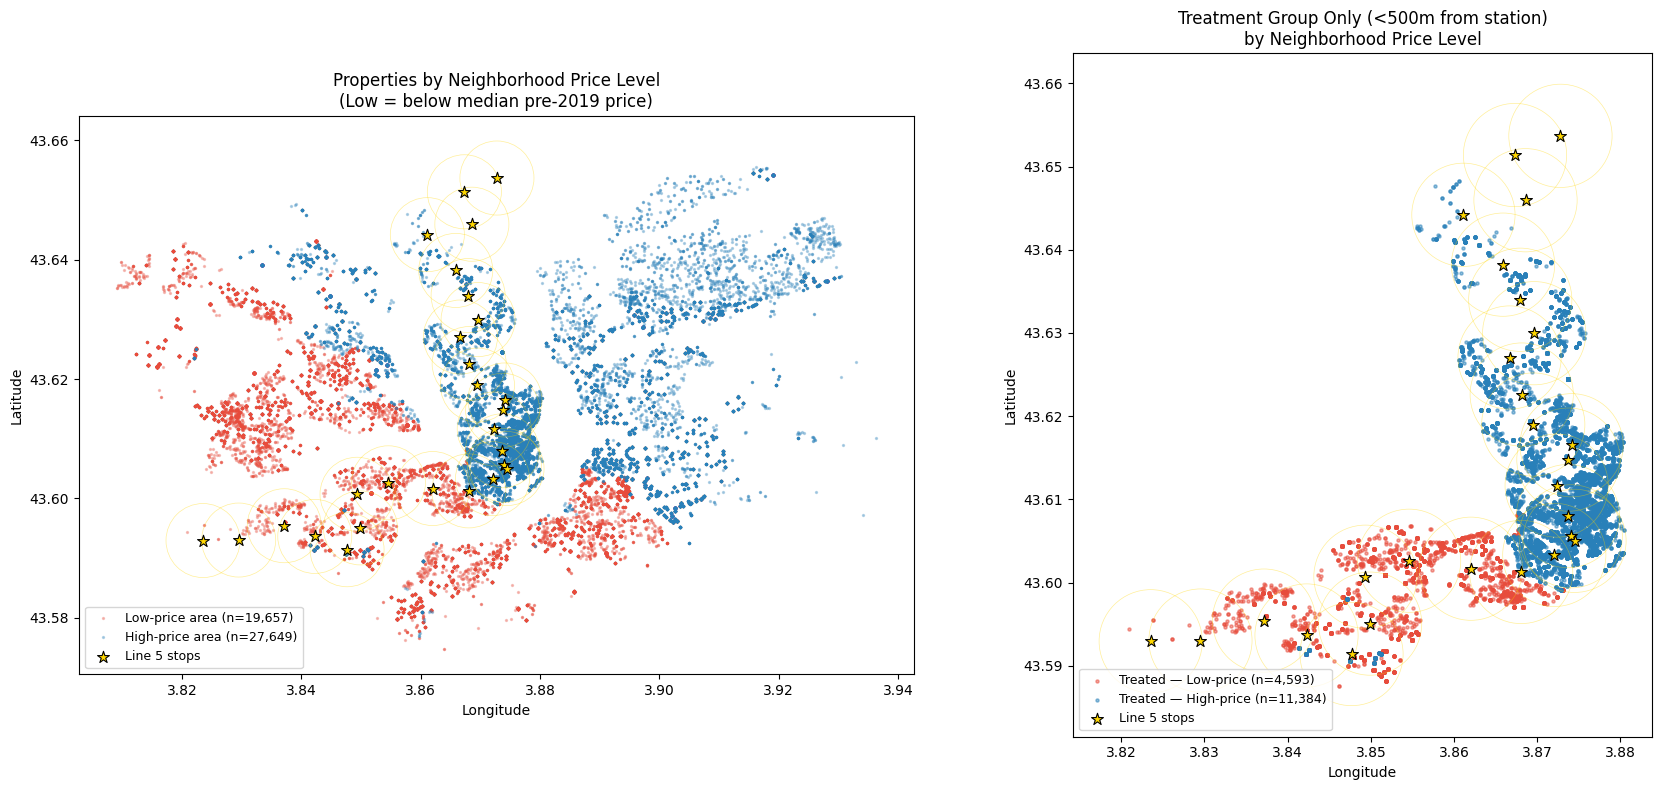


Geographic distribution of treatment group:
  34000: 7,400 treated properties, 0% in low-price area
  34070: 4,593 treated properties, 100% in low-price area
  34090: 3,984 treated properties, 0% in low-price area


In [35]:
# ── 6. Map: Low-price vs High-price areas ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 6a. All properties colored by price group
for val, label, color in [(1, 'Low-price area', '#e74c3c'), (0, 'High-price area', '#2980b9')]:
    sub = df_did_clean[df_did_clean['low_price_area'] == val]
    axes[0].scatter(sub['longitude'], sub['latitude'],
                    c=color, s=2, alpha=0.3, label=f'{label} (n={len(sub):,})')

# Line 5 stops
axes[0].scatter(line5_array[:, 1], line5_array[:, 0],
                c='gold', s=80, marker='*', edgecolors='black',
                linewidths=0.8, zorder=6, label='Line 5 stops')

# 500m buffer circles around stops (visual reference)
for lat, lon in line5_array:
    circle = plt.Circle((lon, lat), 0.5 / (111.32 * np.cos(np.radians(lat))),
                         fill=False, color='gold', linewidth=0.5, alpha=0.4)
    axes[0].add_patch(circle)

axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Properties by Neighborhood Price Level\n(Low = below median pre-2019 price)')
axes[0].legend(fontsize=9, loc='lower left')
axes[0].set_aspect('equal')

# 6b. Treatment group only, colored by price group
for val, label, color in [(1, 'Treated — Low-price', '#e74c3c'), (0, 'Treated — High-price', '#2980b9')]:
    sub = df_did_clean[(df_did_clean['treatment'] == 1) & (df_did_clean['low_price_area'] == val)]
    axes[1].scatter(sub['longitude'], sub['latitude'],
                    c=color, s=5, alpha=0.5, label=f'{label} (n={len(sub):,})')

axes[1].scatter(line5_array[:, 1], line5_array[:, 0],
                c='gold', s=80, marker='*', edgecolors='black',
                linewidths=0.8, zorder=6, label='Line 5 stops')

for lat, lon in line5_array:
    circle = plt.Circle((lon, lat), 0.5 / (111.32 * np.cos(np.radians(lat))),
                         fill=False, color='gold', linewidth=0.5, alpha=0.4)
    axes[1].add_patch(circle)

axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Treatment Group Only (<500m from station)\nby Neighborhood Price Level')
axes[1].legend(fontsize=9, loc='lower left')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

# Print geographic summary
print(f"\nGeographic distribution of treatment group:")
treated = df_did_clean[df_did_clean['treatment'] == 1]
for cp in sorted(treated['code_postal'].unique()):
    cp_sub = treated[treated['code_postal'] == cp]
    low_pct = cp_sub['low_price_area'].mean() * 100
    print(f"  {cp}: {len(cp_sub):,} treated properties, {low_pct:.0f}% in low-price area")

In [ ]:

# SAVE STATE : This is needed for the GBM notebook that feeds the analysis ofthe discussion part 

import pickle
from pathlib import Path

# Pooled metro sample = V10 cleaning over the 5 P1 postal codes,
# WITHOUT the 2 km corridor restriction (so we keep the full metro pool
# as the base for the GBM, and derive corridor subsets from it).
df_metro = filter_corridor(df, P1_POSTAL_CODES)
df_metro["dist_line5_km"] = calc_dist_to_stops(df_metro, line5_array)
df_metro["dist_p1_km"]    = calc_dist_to_stops(df_metro, p1_stops)

state = {
    "P1_POSTAL_CODES": P1_POSTAL_CODES,
    "P2_POSTAL_CODES": P2_POSTAL_CODES,
    "line5_array":     line5_array,   # (n,2) [lat, lon]
    "p1_stops":        p1_stops,      # Bustram A Phase 1 stops
    "p2_stops":        p2_stops,      # Bustram A Phase 2 stops
    "df_metro":        df_metro,      # pooled metro, V10-cleaned
    "df_p1":           df_p1,         # Bustram corridor (≤2 km from P1)
    "df_p2":           df_p2,         # Phase 2 corridor
}
state_path = Path(DATA_DIR) / "v10_state.pkl"
with open(state_path, "wb") as f:
    pickle.dump(state, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f" Saved V10 state → {state_path}")
print(f"  df_metro (metro pool):     {len(df_metro):,} rows")
print(f"  df_p1   (Bustram corridor):{len(df_p1):,} rows")
print(f"  df_p2   (Phase 2 corridor):{len(df_p2):,} rows")

✓ Saved V10 state → /Users/castetpaul/Downloads/MemoireDATA/v10_state.pkl
  df_metro (metro pool):     51,882 rows
  df_p1   (Bustram corridor):23,165 rows
  df_p2   (Phase 2 corridor):8,947 rows


In [ ]:

# STOCK-BASED AGGREGATE UPLIFT — Line 5, properties within 500 m
import numpy as np
from scipy.spatial import cKDTree

# ---- Parameters (state and cite in §5.3) ----
CONSTRUCTION_COST = 440_000_000     # €, Montpellier Méditerranée Métropole (2025)
TURNOVER_RATE     = 0.030           # annual share of residential stock sold (https://www.igedd.developpement-durable.gouv.fr/prix-immobilier-evolution-a-long-terme-a1048.html)
TURNOVER_BAND     = (0.030, 0.040)  # realised range, early-2000s low to Covid peak (Friggit, 2024)
DWELLING_DENSITY = 3_000            # dwellings/km²: 171,255 logements (INSEE RP2018) / 56.88 km²; ~2,900 in 2015
BUFFER_KM         = 0.5             # We take only the properties in the 500m

# ---- Premium and 95% CI, read live from M3 ----
try:
    PREMIUM = float(model3.params['did_construction_start'])
    lo_ci, hi_ci = model3.conf_int().loc['did_construction_start']
    PREMIUM_CI = (float(lo_ci), float(hi_ci))
except NameError:                   # fallback to reported M3 values
    PREMIUM, PREMIUM_CI = 173.62, (127.07, 220.17)

treated      = df_did_clean[df_did_clean['treatment'] == 1]
N_TREATED    = len(treated)
MEAN_SURFACE = treated['surface_reelle_bati'].mean()   # proxy for stock mean surface
N_YEARS      = treated['year'].nunique()               # observed years (2020 dropped)

def uplift_eur(n_dwellings, premium=PREMIUM):
    return n_dwellings * MEAN_SURFACE * premium

print(f"Treated transactions: {N_TREATED:,}  |  mean surface: {MEAN_SURFACE:.1f} m²  |  "
      f"observed years: {N_YEARS}")
print(f"Premium (M3): €{PREMIUM:.0f}/m²  [95% CI {PREMIUM_CI[0]:.0f}, {PREMIUM_CI[1]:.0f}]\n")

# ---- Route 1: turnover-implied standing stock  (N ≈ τ · stock · T) ----
stock_turnover = N_TREATED / (TURNOVER_RATE * N_YEARS)
print(f"[1] turnover      : {stock_turnover:>7,.0f} dwellings  "
      f"→ €{uplift_eur(stock_turnover)/1e6:>4,.0f} M   (leans high)")

# ---- Route 2: 500 m buffer-union area × density (numpy; no turnover) ----
mean_lat = np.radians(line5_array[:, 0].mean())
stops_km = np.column_stack([
    line5_array[:, 0] * 111.32,
    line5_array[:, 1] * 111.32 * np.cos(mean_lat),
])
margin = BUFFER_KM + 0.05
step   = 0.01                                          # 10 m grid
gx, gy = np.meshgrid(
    np.arange(stops_km[:, 0].min() - margin, stops_km[:, 0].max() + margin, step),
    np.arange(stops_km[:, 1].min() - margin, stops_km[:, 1].max() + margin, step),
)
grid = np.column_stack([gx.ravel(), gy.ravel()])
dmin, _ = cKDTree(stops_km).query(grid, k=1)
area_km2   = (dmin <= BUFFER_KM).sum() * step * step
stock_area = area_km2 * DWELLING_DENSITY
print(f"[2] area×density  : {stock_area:>7,.0f} dwellings  "
      f"→ €{uplift_eur(stock_area)/1e6:>4,.0f} M   "
      f"({area_km2:.1f} km² × {DWELLING_DENSITY:,}/km²; leans low)")

# ---- Bracket, floor, sensitivity ----
stock_lo, stock_hi = sorted([stock_turnover, stock_area])
up_lo,    up_hi    = uplift_eur(stock_lo), uplift_eur(stock_hi)
floor              = N_TREATED * MEAN_SURFACE * PREMIUM

print("\n" + "=" * 66)
print(f"STOCK-BASED BRACKET : €{up_lo/1e6:,.0f}–{up_hi/1e6:,.0f} M  "
      f"({up_lo/CONSTRUCTION_COST*100:.0f}–{up_hi/CONSTRUCTION_COST*100:.0f}% of "
      f"€{CONSTRUCTION_COST/1e6:.0f} M cost)")
print(f"LOWER BOUND (txn)   : €{floor/1e6:,.0f} M  ({floor/CONSTRUCTION_COST*100:.0f}% of cost)")
print("=" * 66)

print("\nUplift (€M) by premium:       "
      + "".join(f"{lbl} €{p:.0f}".rjust(16)
               for lbl, p in [("CI-lo", PREMIUM_CI[0]), ("point", PREMIUM), ("CI-hi", PREMIUM_CI[1])]))
for name, s in [("turnover", stock_turnover), ("area×density", stock_area)]:
    print(f"  {name:<14}" + "".join(
        f"{uplift_eur(s, p)/1e6:>16,.0f}" for p in [PREMIUM_CI[0], PREMIUM, PREMIUM_CI[1]]))

s_lo = N_TREATED / (TURNOVER_BAND[1] * N_YEARS)
s_hi = N_TREATED / (TURNOVER_BAND[0] * N_YEARS)
print(f"\nTurnover τ ∈ [{TURNOVER_BAND[0]:.0%}, {TURNOVER_BAND[1]:.0%}] → stock "
      f"{s_lo:,.0f}–{s_hi:,.0f}, uplift €{uplift_eur(s_lo)/1e6:,.0f}–{uplift_eur(s_hi)/1e6:,.0f} M")


Treated transactions: 15,977  |  mean surface: 58.1 m²  |  observed years: 10
Premium (M3): €174/m²  [95% CI 127, 220]

[1] turnover      :  45,649 dwellings  → € 460 M   (leans high)
[2] area×density  :  35,194 dwellings  → € 355 M   (12.1 km² × 2,900/km²; leans low)

STOCK-BASED BRACKET : €355–460 M  (81–105% of €440 M cost)
LOWER BOUND (txn)   : €161 M  (37% of cost)

Uplift (€M) by premium:             CI-lo €127      point €174      CI-hi €220
  turnover                   337             460             584
  area×density               260             355             450

Turnover τ ∈ [3%, 4%] → stock 39,942–53,257, uplift €403–537 M
